# 02 - Khảo Sát & Khám Phá Dữ Liệu Khí Tượng ERA5 (EDA)
### Dự án: Dự Báo Lượng Mưa Cực Ngắn (Rainfall Nowcasting) tại Việt Nam
---

Notebook này thực hiện phân tích khám phá dữ liệu (Exploratory Data Analysis - EDA) toàn diện trên tập dữ liệu khí tượng tái phân tích toàn cầu **ERA5** (giai đoạn 2023 - 2025) phục vụ cho bài toán huấn luyện mô hình học sâu và mô hình vật lý khí quyển (PINN / ConvLSTM / Transformers).

### Các điểm nâng cấp & nổi bật trong phân tích này:
1. **Bản đồ Hành chính & Chủ quyền Biển đảo chuẩn Quốc gia:**
   - Tích hợp ranh giới phân định **34 đơn vị hành chính Việt Nam** (năm 2026).
   - Hiển thị ranh giới quốc gia, vùng biển lân cận Đông Nam Á.
   - **Đường bao (Bounding Box) nổi bật và nhãn chủ quyền** cho **Quần đảo Hoàng Sa** và **Quần đảo Trường Sa**, cùng các đảo tiền tiêu: Phú Quốc, Côn Đảo, Bạch Long Vĩ, Lý Sơn, Cồn Cỏ, Phú Quý.
2. **Trực quan hoá Đa biến Không gian - Thời gian (Spatiotemporal Multi-variable Analysis):**
   - Phân tích tương tác giữa 5 biến số vật lý: Lượng mưa ($tp$), Nhiệt độ 2m ($t_{2m}$), Khí áp mực biển ($msl$), Vận tốc và Hướng gió ($u_{10}, v_{10}, ws$).
   - Minh họa trường vector gió (Quiver & Streamlines) trên nền khí áp và lượng mưa để thể hiện các hoàn lưu gió mùa và xoáy thuận nhiệt đới.
3. **Phân tích Phân phối Thống kê & Hiện tượng Zero-Inflation:**
   - Đánh giá tính chất bất đối xứng cực đoan của lượng mưa (85-90% thời gian tạnh ráo).
   - Phân loại cấp độ mưa theo tiêu chuẩn Khí tượng Việt Nam & Quốc tế.
4. **Phân tích Chu kỳ Theo Mùa, Vùng Miền & Ngày - Đêm (Diurnal Cycle):**
   - Đánh giá sự khác biệt khí hậu giữa 5 phân vùng: Bắc Bộ, Trung Bộ, Nam Bộ, Vùng biển Hoàng Sa, Vùng biển Trường Sa.
   - Chu kỳ ngày đêm (đỉnh mưa đối lưu 14h - 18h theo giờ địa phương ICT).
5. **Truy vết Diễn biến Bão & Sự kiện Mưa Cực đoan Lịch sử:**
   - Tự động phát hiện Top các sự kiện mưa bão lớn nhất 2023-2025.
   - Trích xuất chuỗi không gian - thời gian (Sequence Plot) 8-12 khung hình liên tiếp để quan sát hướng dịch chuyển của tâm mưa.


In [13]:
import os
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import dask
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import seaborn as sns
import geopandas as gpd

# Cấu hình Dask chạy synchronous (single-threaded) để đảm bảo thread-safety tuyệt đối cho thư viện C NetCDF4/HDF5 trên Windows
dask.config.set(scheduler='synchronous')

# Import mô-đun tiện ích GIS bản đồ Việt Nam
from gis_utils import draw_vietnam_map, VIETNAM_ISLANDS_BOUNDS, load_gis_layers

# Thiết lập cấu hình hiển thị biểu đồ
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Segoe UI', 'Liberation Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

print("Đã tải các thư viện và cấu hình hệ thống thành công!")


Đã tải các thư viện và cấu hình hệ thống thành công!


## 1. Tải và Hợp nhất Bộ Dữ liệu ERA5 Đa biến (2023 - 2025)

Dữ liệu được lưu trong thư mục `era5_data/` gồm 2 nhóm file:
- `*_accum.nc`: Chứa biến tích luỹ lượng mưa $tp$ (Total Precipitation).
- `*_instant.nc`: Chứa các biến tức thời gồm $t_{2m}$ (Nhiệt độ 2m), $msl$ (Khí áp mực biển), $u_{10}, v_{10}$ (Vận tốc gió Đông-Tây và Bắc-Nam).


In [14]:
data_dir = Path('era5_data')
if not data_dir.exists():
    raise FileNotFoundError(f"Không tìm thấy thư mục {data_dir}. Vui lòng chạy 01_Download_ERA5.ipynb trước.")

print("1. Đang mở các file Lượng mưa (accum.nc)...")
ds_accum = xr.open_mfdataset(
    str(data_dir / "*_accum.nc"),
    combine="by_coords",
    engine="netcdf4"
)
if 'valid_time' in ds_accum.coords:
    ds_accum = ds_accum.rename({'valid_time': 'time'})

print("2. Đang mở các file Khí quyển (instant.nc)...")
ds_instant = xr.open_mfdataset(
    str(data_dir / "*_instant.nc"),
    combine="by_coords",
    engine="netcdf4"
)
if 'valid_time' in ds_instant.coords:
    ds_instant = ds_instant.rename({'valid_time': 'time'})

print("3. Đang hợp nhất (merge) các biến...")
ds = xr.merge([ds_accum, ds_instant])

# =========================================================================
# CHUYỂN ĐỔI ĐƠN VỊ VẬT LÝ CHUẨN KHÍ TƯỢNG
# =========================================================================
# 1. Lượng mưa: m -> mm
ds['tp'] = ds['tp'] * 1000.0
ds['tp'].attrs['units'] = 'mm'
ds['tp'].attrs['long_name'] = 'Total Precipitation'

# 2. Khí áp mực biển: Pa -> hPa (1 hPa = 100 Pa)
ds['msl'] = ds['msl'] / 100.0
ds['msl'].attrs['units'] = 'hPa'
ds['msl'].attrs['long_name'] = 'Mean Sea Level Pressure'

# 3. Nhiệt độ 2m: Kelvin -> Độ Celsius (°C)
ds['t2m_c'] = ds['t2m'] - 273.15
ds['t2m_c'].attrs['units'] = '°C'
ds['t2m_c'].attrs['long_name'] = '2m Temperature (°C)'

# 4. Tốc độ gió tổng hợp (Wind Speed): sqrt(u^2 + v^2) (m/s)
ds['ws'] = np.sqrt(ds['u10']**2 + ds['v10']**2)
ds['ws'].attrs['units'] = 'm/s'
ds['ws'].attrs['long_name'] = '10m Wind Speed'

# 5. Hướng gió khí tượng (Wind Direction): 0° là gió Bắc, 90° gió Đông
ds['wdir'] = (np.arctan2(-ds['u10'], -ds['v10']) * 180 / np.pi) % 360
ds['wdir'].attrs['units'] = 'degrees'
ds['wdir'].attrs['long_name'] = '10m Wind Direction'

print("\n" + "="*60)
print("THÔNG TIN BỘ DỮ LIỆU ĐÃ HỢP NHẤT:")
print(f"- Khoảng thời gian: từ {ds.time.values[0]} đến {ds.time.values[-1]}")
print(f"- Tổng số bước thời gian (Hourly steps): {len(ds.time):,} frames")
print(f"- Kích thước lưới không gian: {len(ds.latitude)} x {len(ds.longitude)} (Lat x Lon)")
print(f"- Phạm vi toạ độ: Vĩ độ [{ds.latitude.values.min()}°N, {ds.latitude.values.max()}°N], Kinh độ [{ds.longitude.values.min()}°E, {ds.longitude.values.max()}°E]")
print(f"- Độ phân giải lưới: 0.25° x 0.25° (~ 27.75 km)")
print(f"- Các biến số: {list(ds.data_vars.keys())}")
print("="*60)


1. Đang mở các file Lượng mưa (accum.nc)...
2. Đang mở các file Khí quyển (instant.nc)...
3. Đang hợp nhất (merge) các biến...

THÔNG TIN BỘ DỮ LIỆU ĐÃ HỢP NHẤT:
- Khoảng thời gian: từ 2023-01-01T00:00:00.000000000 đến 2025-12-31T23:00:00.000000000
- Tổng số bước thời gian (Hourly steps): 26,304 frames
- Kích thước lưới không gian: 81 x 81 (Lat x Lon)
- Phạm vi toạ độ: Vĩ độ [5.0°N, 25.0°N], Kinh độ [100.0°E, 120.0°E]
- Độ phân giải lưới: 0.25° x 0.25° (~ 27.75 km)
- Các biến số: ['tp', 'u10', 'v10', 't2m', 'msl', 't2m_c', 'ws', 'wdir']


## 2. Kiểm tra Toàn vẹn & Thống kê Tóm tắt Chất lượng Dữ liệu

Trước khi xây dựng mô hình, ta kiểm tra các giá trị khuyết thiếu (NaN / Missing Values), dải giá trị Min-Max và các phân vị để đảm bảo dữ liệu chuẩn xác 100%.


In [15]:
# Lấy mẫu thời gian (mỗi 4 giờ trong 1 năm = hơn 14 triệu điểm dữ liệu) để thống kê siêu nhanh
sample_ds = ds.isel(time=slice(0, 8760, 4))

summary_rows = []
variables = ['tp', 't2m_c', 'msl', 'ws', 'u10', 'v10']

for var in variables:
    data_var = sample_ds[var]
    # Lấy mảng numpy một lần để tính toán nhanh và tránh lỗi Dask nanmedian
    data_np = data_var.values
    nan_count = int(np.isnan(data_np).sum())
    v_min = float(np.nanmin(data_np))
    v_max = float(np.nanmax(data_np))
    v_mean = float(np.nanmean(data_np))
    v_std = float(np.nanstd(data_np))
    v_q50 = float(np.nanmedian(data_np))
    units = data_var.attrs.get('units', '')
    
    summary_rows.append({
        'Biến số': var,
        'Tên đầy đủ': data_var.attrs.get('long_name', var),
        'Đơn vị': units,
        'Số NaN': nan_count,
        'Tỷ lệ NaN (%)': f"{nan_count / data_np.size * 100:.2f}%",
        'Min': f"{v_min:.2f}",
        'Median (Q50)': f"{v_q50:.2f}",
        'Mean': f"{v_mean:.2f}",
        'Max': f"{v_max:.2f}",
        'Std': f"{v_std:.2f}"
    })

df_summary = pd.DataFrame(summary_rows)
print("BẢNG THỐNG KÊ TÓM TẮT METADATA & DATA QUALITY:")
display(df_summary)


BẢNG THỐNG KÊ TÓM TẮT METADATA & DATA QUALITY:


,Biến số,Tên đầy đủ,Đơn vị,Số NaN,Tỷ lệ NaN (%),Min,Median (Q50),Mean,Max,Std
0,tp,Total Precipitation,mm,0,0.00%,0.00,0.01,0.21,39.97,0.65
1,t2m_c,2m Temperature (°C),°C,0,0.00%,-3.36,27.08,25.92,43.72,4.32
2,msl,Mean Sea Level Pressure,hPa,0,0.00%,974.18,1010.43,1011.04,1039.64,4.72
3,ws,10m Wind Speed,m/s,0,0.00%,0.00,3.72,4.50,27.93,3.22
4,u10,10 metre U wind component,m s**-1,0,0.00%,-25.55,-0.76,-0.94,22.55,3.82
5,v10,10 metre V wind component,m s**-1,0,0.00%,-24.61,0.03,-0.42,26.99,3.87


## 3. Trực quan hoá Đa biến Không gian với Ranh giới 34 Đơn vị Hành chính & Quần đảo Chủ quyền

Dưới đây là biểu đồ bản đồ 4 khung hình (Multi-panel Spatial Plot) hiển thị đồng thời 4 trường biến khí tượng tại cùng một thời điểm:
1. **Lượng mưa ($tp$)**: Thể hiện tâm mưa đối lưu và dải hội tụ nhiệt đới.
2. **Nhiệt độ bề mặt 2m ($t_{2m}$)**: Thể hiện sự chênh lệch nhiệt giữa đất liền và biển Đông.
3. **Khí áp mực biển ($msl$)**: Thể hiện các tâm áp cao / áp thấp (rãnh áp thấp).
4. **Trường Gió ($ws$ & Vector Quiver)**: Thể hiện hướng gió và vận tốc gió bề mặt.

Bản đồ được trang bị đầy đủ:
- **Đường viền ranh giới 34 đơn vị hành chính Việt Nam năm 2026** sắc nét.
- **Khung bao bọc (Bounding Box nét đứt màu đỏ) và nhãn chủ quyền** cho **Quần đảo Hoàng Sa (Đà Nẵng)** và **Quần đảo Trường Sa (Khánh Hòa)**.
- Đánh dấu các đảo: Phú Quốc, Côn Đảo, Bạch Long Vĩ.


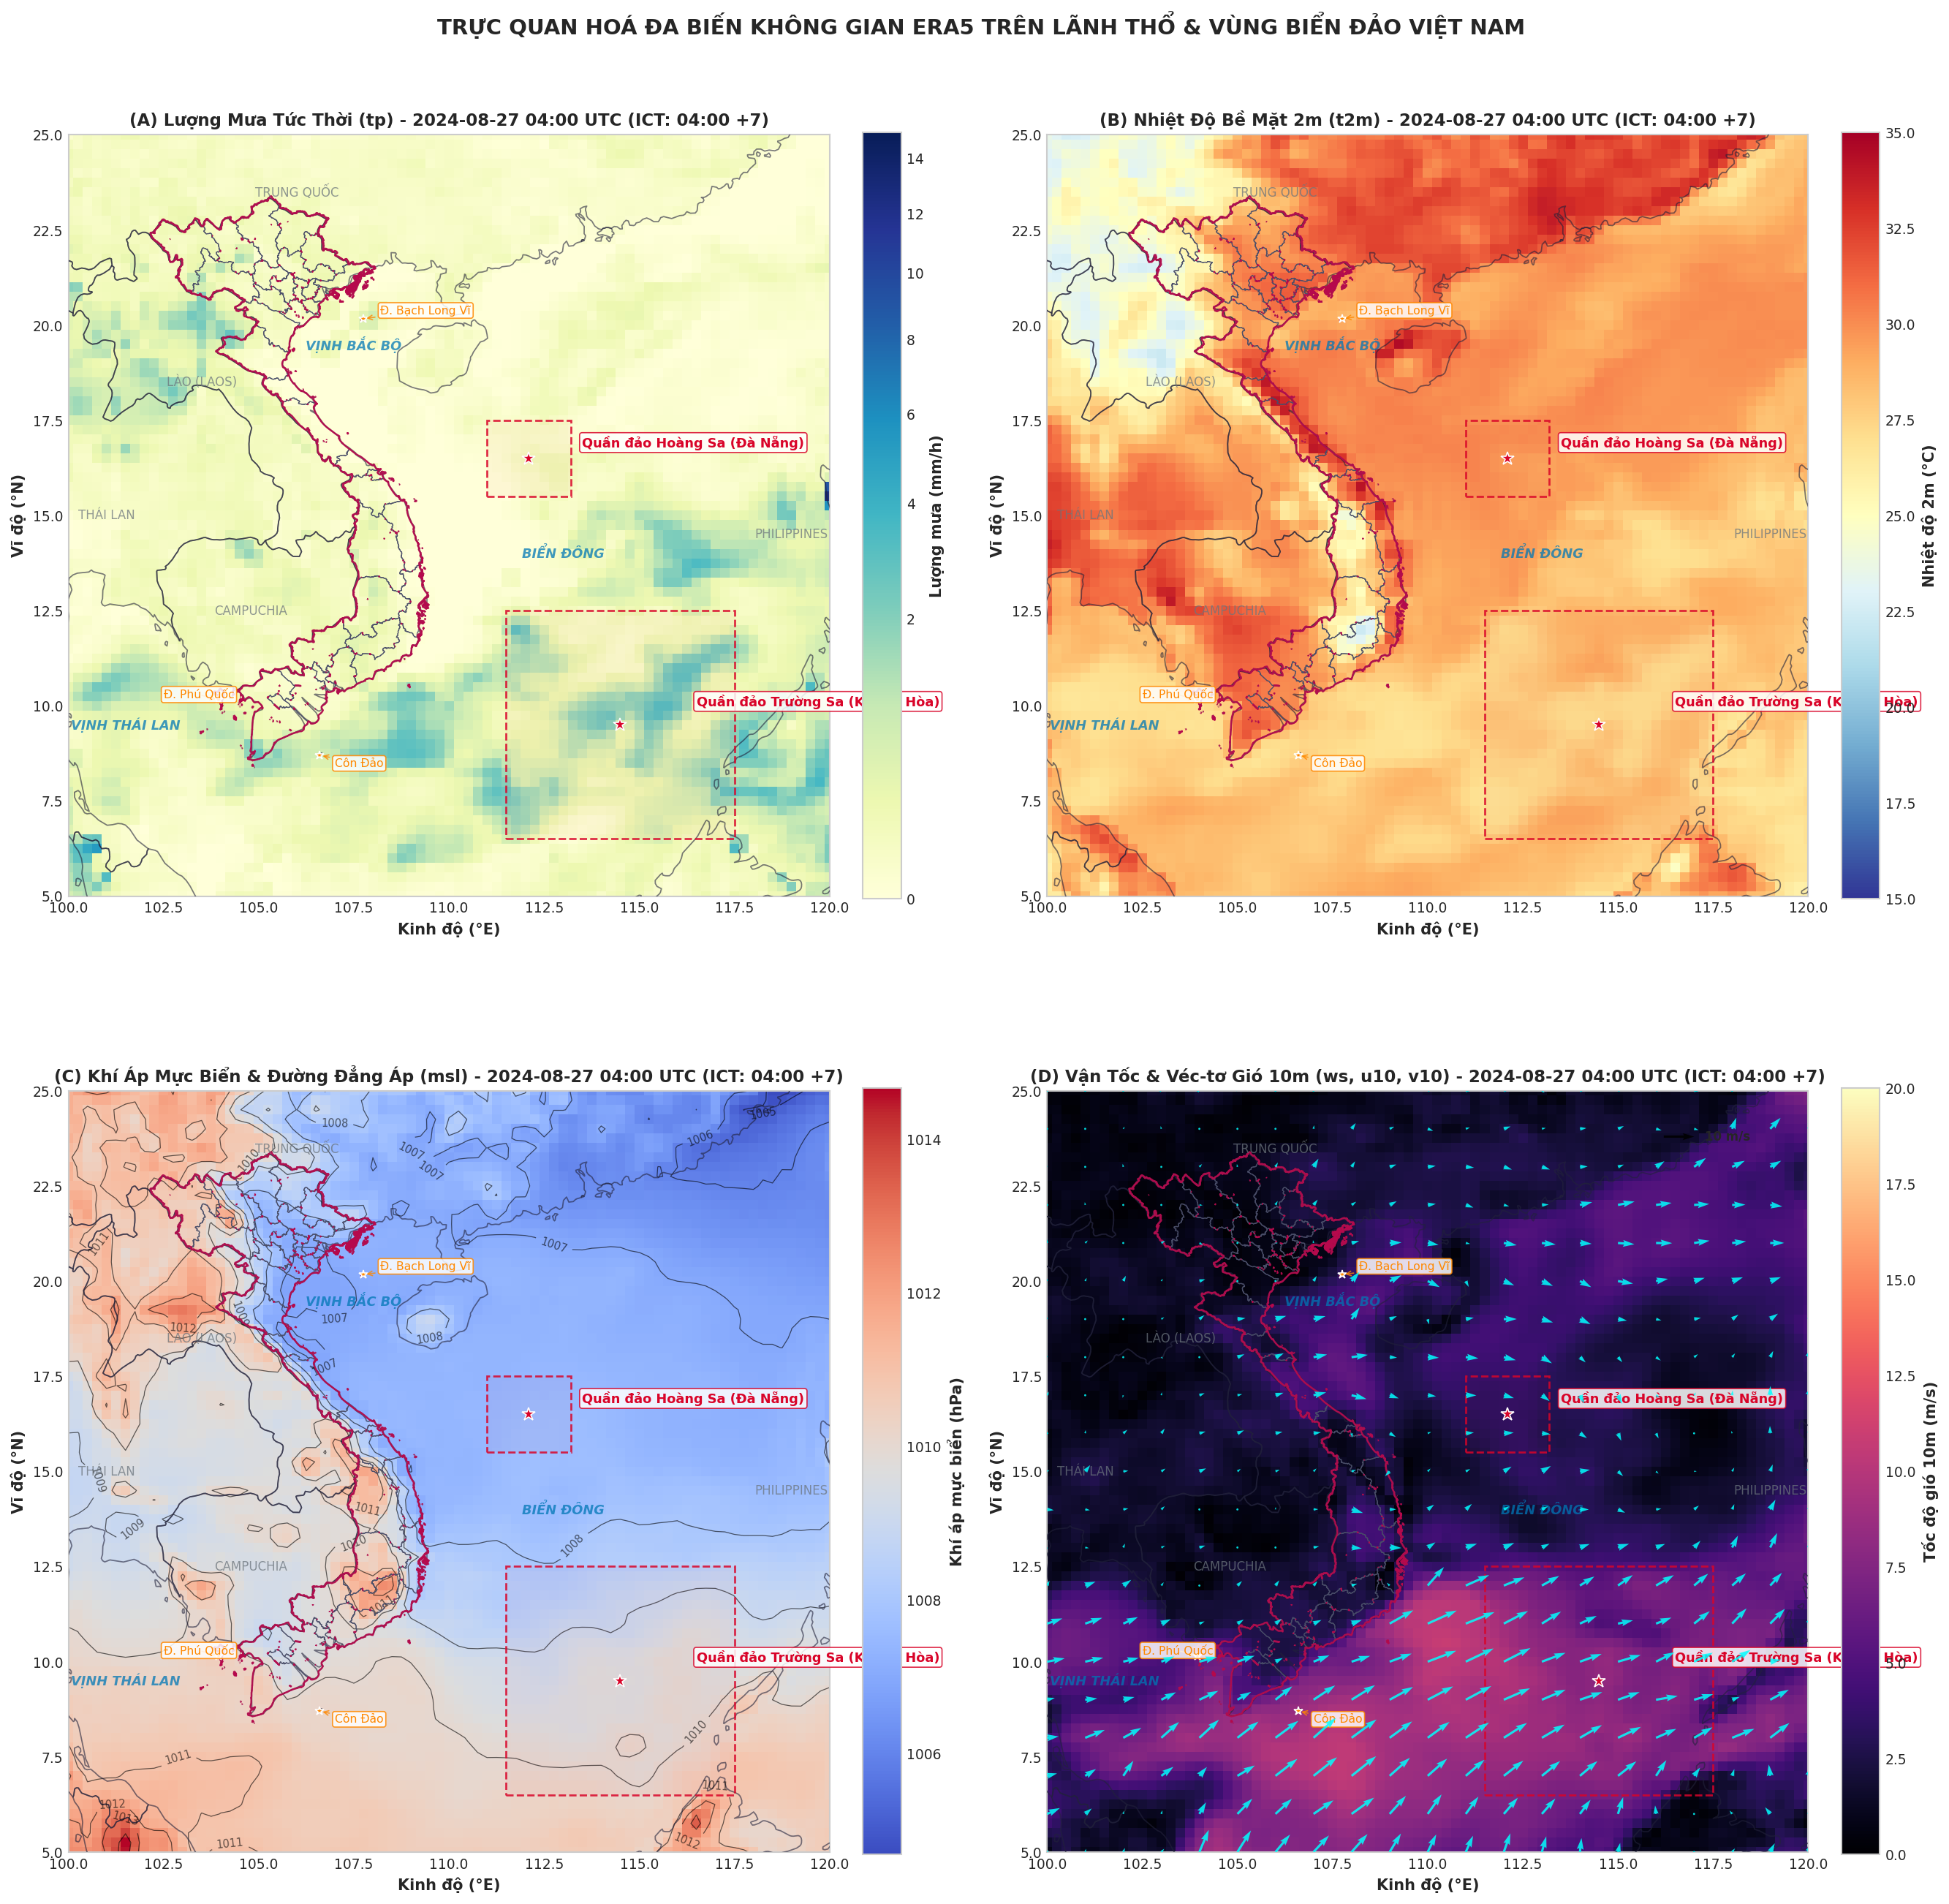

Đã lưu biểu đồ vào img/01_multivariable_spatial_map.png


In [16]:
# Chọn một thời điểm có thời tiết sôi động (Mùa mưa bão tháng 9 - 10)
target_time = '2024-09-15T12:00:00'
if target_time not in ds.time.values.astype(str):
    target_idx = 14500 # Chọn một frame mẫu ngẫu nhiên
    target_time_val = ds.time.values[target_idx]
else:
    target_time_val = np.datetime64(target_time)

snapshot = ds.sel(time=target_time_val).compute()
time_str = pd.to_datetime(str(snapshot.time.values)).strftime('%Y-%m-%d %H:00 UTC (ICT: %H:00 +7)')

fig, axes = plt.subplots(2, 2, figsize=(18, 18), dpi=150)
lons, lats = np.meshgrid(ds.longitude.values, ds.latitude.values)

# -------------------------------------------------------------
# 1. Lượng mưa (Total Precipitation)
# -------------------------------------------------------------
ax1 = axes[0, 0]
cmap_rain = plt.cm.YlGnBu
norm_rain = mcolors.PowerNorm(gamma=0.5, vmin=0, vmax=max(float(snapshot['tp'].max()), 15.0))

im1 = ax1.pcolormesh(lons, lats, snapshot['tp'].values, cmap=cmap_rain, norm=norm_rain, shading='auto')
draw_vietnam_map(ax1, show_provinces=True, show_islands=True, show_islands_box=True)
cb1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cb1.set_label('Lượng mưa (mm/h)', fontsize=10, fontweight='bold')
ax1.set_title(f"(A) Lượng Mưa Tức Thời (tp) - {time_str}", fontsize=11, fontweight='bold')

# -------------------------------------------------------------
# 2. Nhiệt độ bề mặt 2m (2m Temperature)
# -------------------------------------------------------------
ax2 = axes[0, 1]
cmap_temp = plt.cm.RdYlBu_r
im2 = ax2.pcolormesh(lons, lats, snapshot['t2m_c'].values, cmap=cmap_temp, vmin=15, vmax=35, shading='auto')
draw_vietnam_map(ax2, show_provinces=True, show_islands=True, show_islands_box=True)
cb2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cb2.set_label('Nhiệt độ 2m (°C)', fontsize=10, fontweight='bold')
ax2.set_title(f"(B) Nhiệt Độ Bề Mặt 2m (t2m) - {time_str}", fontsize=11, fontweight='bold')

# -------------------------------------------------------------
# 3. Khí áp mực biển (Mean Sea Level Pressure)
# -------------------------------------------------------------
ax3 = axes[1, 0]
cmap_msl = plt.cm.coolwarm
im3 = ax3.pcolormesh(lons, lats, snapshot['msl'].values, cmap=cmap_msl, shading='auto')
# Vẽ đường đẳng áp (Isobar Contours)
cs = ax3.contour(lons, lats, snapshot['msl'].values, levels=10, colors='black', linewidths=0.6, alpha=0.6)
ax3.clabel(cs, inline=True, fontsize=7, fmt='%1.0f')
draw_vietnam_map(ax3, show_provinces=True, show_islands=True, show_islands_box=True)
cb3 = fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
cb3.set_label('Khí áp mực biển (hPa)', fontsize=10, fontweight='bold')
ax3.set_title(f"(C) Khí Áp Mực Biển & Đường Đẳng Áp (msl) - {time_str}", fontsize=11, fontweight='bold')

# -------------------------------------------------------------
# 4. Trường Gió: Tốc độ gió + Vector hướng gió (Quiver)
# -------------------------------------------------------------
ax4 = axes[1, 1]
cmap_ws = plt.cm.magma
im4 = ax4.pcolormesh(lons, lats, snapshot['ws'].values, cmap=cmap_ws, vmin=0, vmax=20, shading='auto')

skip = 4
q = ax4.quiver(
    lons[::skip, ::skip],
    lats[::skip, ::skip],
    snapshot['u10'].values[::skip, ::skip],
    snapshot['v10'].values[::skip, ::skip],
    color='cyan',
    scale=250,
    width=0.003,
    alpha=0.85,
    zorder=9
)
ax4.quiverkey(q, 0.85, 0.94, 10, '10 m/s', labelpos='E', coordinates='axes', color='black', fontproperties={'weight': 'bold', 'size': 8})
draw_vietnam_map(ax4, show_provinces=True, show_islands=True, show_islands_box=True)
cb4 = fig.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
cb4.set_label('Tốc độ gió 10m (m/s)', fontsize=10, fontweight='bold')
ax4.set_title(f"(D) Vận Tốc & Véc-tơ Gió 10m (ws, u10, v10) - {time_str}", fontsize=11, fontweight='bold')

plt.suptitle("TRỰC QUAN HOÁ ĐA BIẾN KHÔNG GIAN ERA5 TRÊN LÃNH THỔ & VÙNG BIỂN ĐẢO VIỆT NAM", fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
os.makedirs('img', exist_ok=True)
plt.savefig('img/01_multivariable_spatial_map.png', dpi=200, bbox_inches='tight')
plt.show()
print("Đã lưu biểu đồ vào img/01_multivariable_spatial_map.png")


## 4. Phân tích Khí động học: Tương tác Trường Gió và Lượng Mưa (Advection & Streamlines)

Trong mô hình **Physics-Informed Neural Network (PINN / ThoR Framework)**, lượng mưa được giả định chịu sự chi phối của phương trình bình lưu - khuếch tán:
$$\frac{\partial P}{\partial t} + u_{10} \frac{\partial P}{\partial x} + v_{10} \frac{\partial P}{\partial y} = D \nabla^2 P + S$$

Dưới đây ta trực quan hoá đường dòng (Streamlines) của vector gió $(u_{10}, v_{10})$ chồng trực tiếp lên trường lượng mưa để kiểm tra xem mây mưa có di chuyển dọc theo các đường dòng của vector gió hay không.


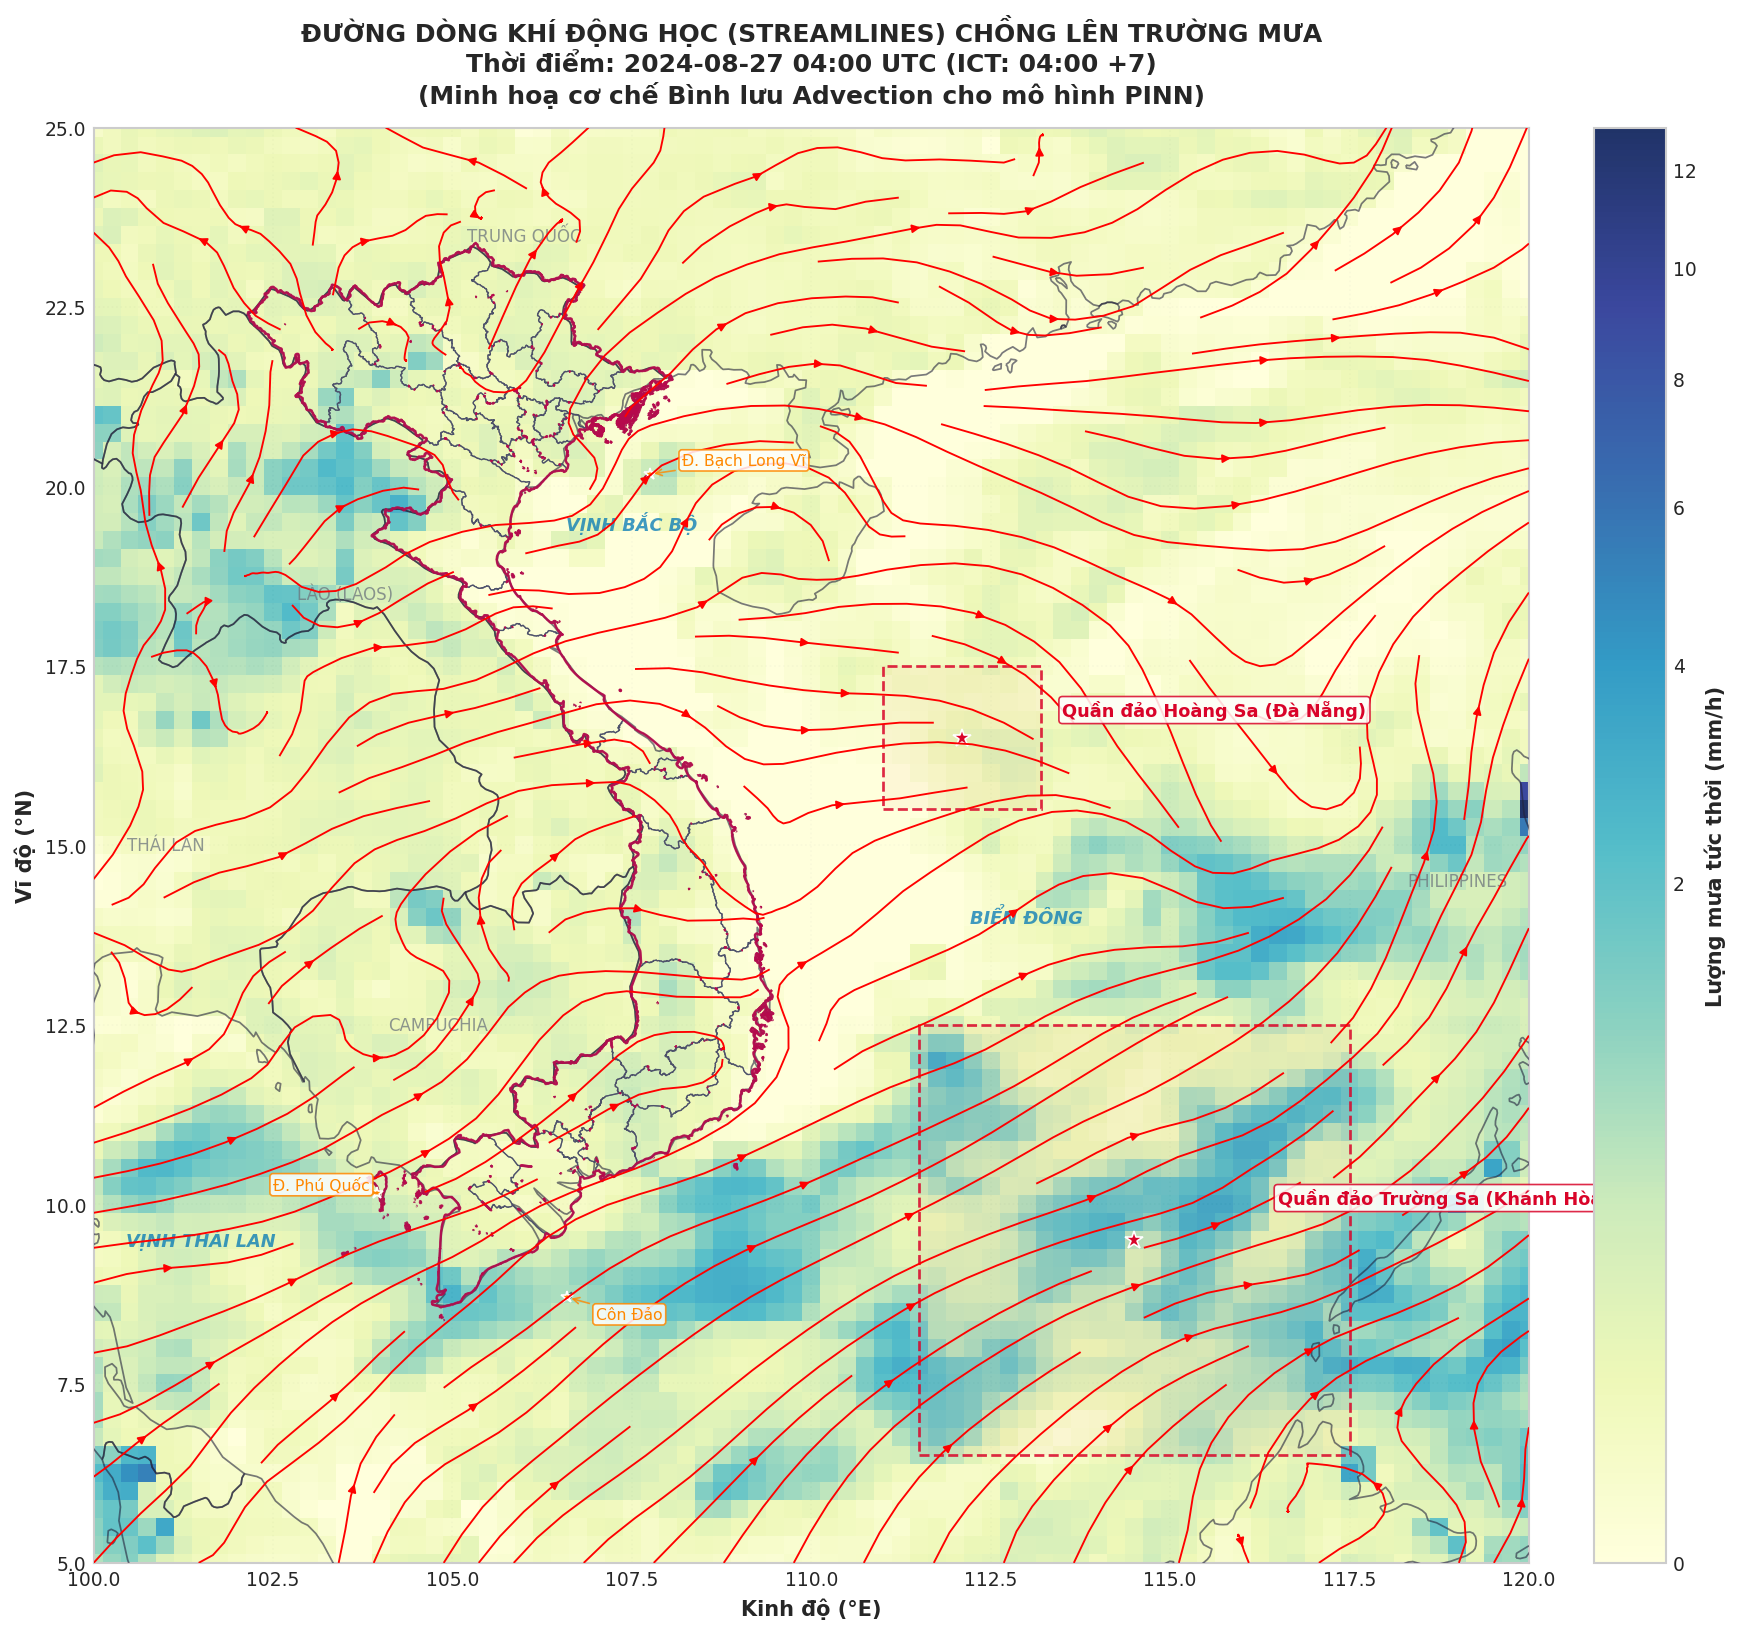

In [17]:
fig, ax = plt.subplots(figsize=(12, 11), dpi=150)

# 1. Vẽ trường lượng mưa nền
norm_rain = mcolors.PowerNorm(gamma=0.4, vmin=0, vmax=max(float(snapshot['tp'].max()), 10.0))
im = ax.pcolormesh(lons, lats, snapshot['tp'].values, cmap='YlGnBu', norm=norm_rain, shading='auto', alpha=0.9)

# 2. Vẽ đường dòng khí động học (Streamplot)
lat_asc = ds.latitude.values[::-1]
u_asc = snapshot['u10'].values[::-1, :]
v_asc = snapshot['v10'].values[::-1, :]

strm = ax.streamplot(
    ds.longitude.values,
    lat_asc,
    u_asc,
    v_asc,
    color='red',
    density=1.4,
    linewidth=0.9,
    arrowsize=0.8,
    zorder=8
)

# 3. Vẽ ranh giới bản đồ Việt Nam và các đảo Hoàng Sa, Trường Sa
draw_vietnam_map(ax, show_provinces=True, show_islands=True, show_islands_box=True)

cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label('Lượng mưa tức thời (mm/h)', fontsize=10, fontweight='bold')

ax.set_title(f"ĐƯỜNG DÒNG KHÍ ĐỘNG HỌC (STREAMLINES) CHỒNG LÊN TRƯỜNG MƯA\nThời điểm: {time_str}\n(Minh hoạ cơ chế Bình lưu Advection cho mô hình PINN)", fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('img/02_wind_streamlines_rain_advection.png', dpi=200, bbox_inches='tight')
plt.show()


## 5. Phân tích Thống kê Phân phối & Vấn đề Cực kỳ Mất cân bằng (Zero-Inflation)

### Thách thức lớn nhất trong Dự báo Lượng mưa:
- Lượng mưa có tính chất **Zero-inflated (thời gian tạnh ráo chiếm tuyệt đại đa số)**.
- Nếu dùng hàm mất mát MSE thông thường, mô hình AI sẽ rơi vào trạng thái *"lười biếng"* (luôn đoán bằng 0 để đạt Loss thấp nhất).
- Ta cần phân loại cụ thể các ngưỡng mưa và kiểm tra phân phối $\log(1 + tp)$.


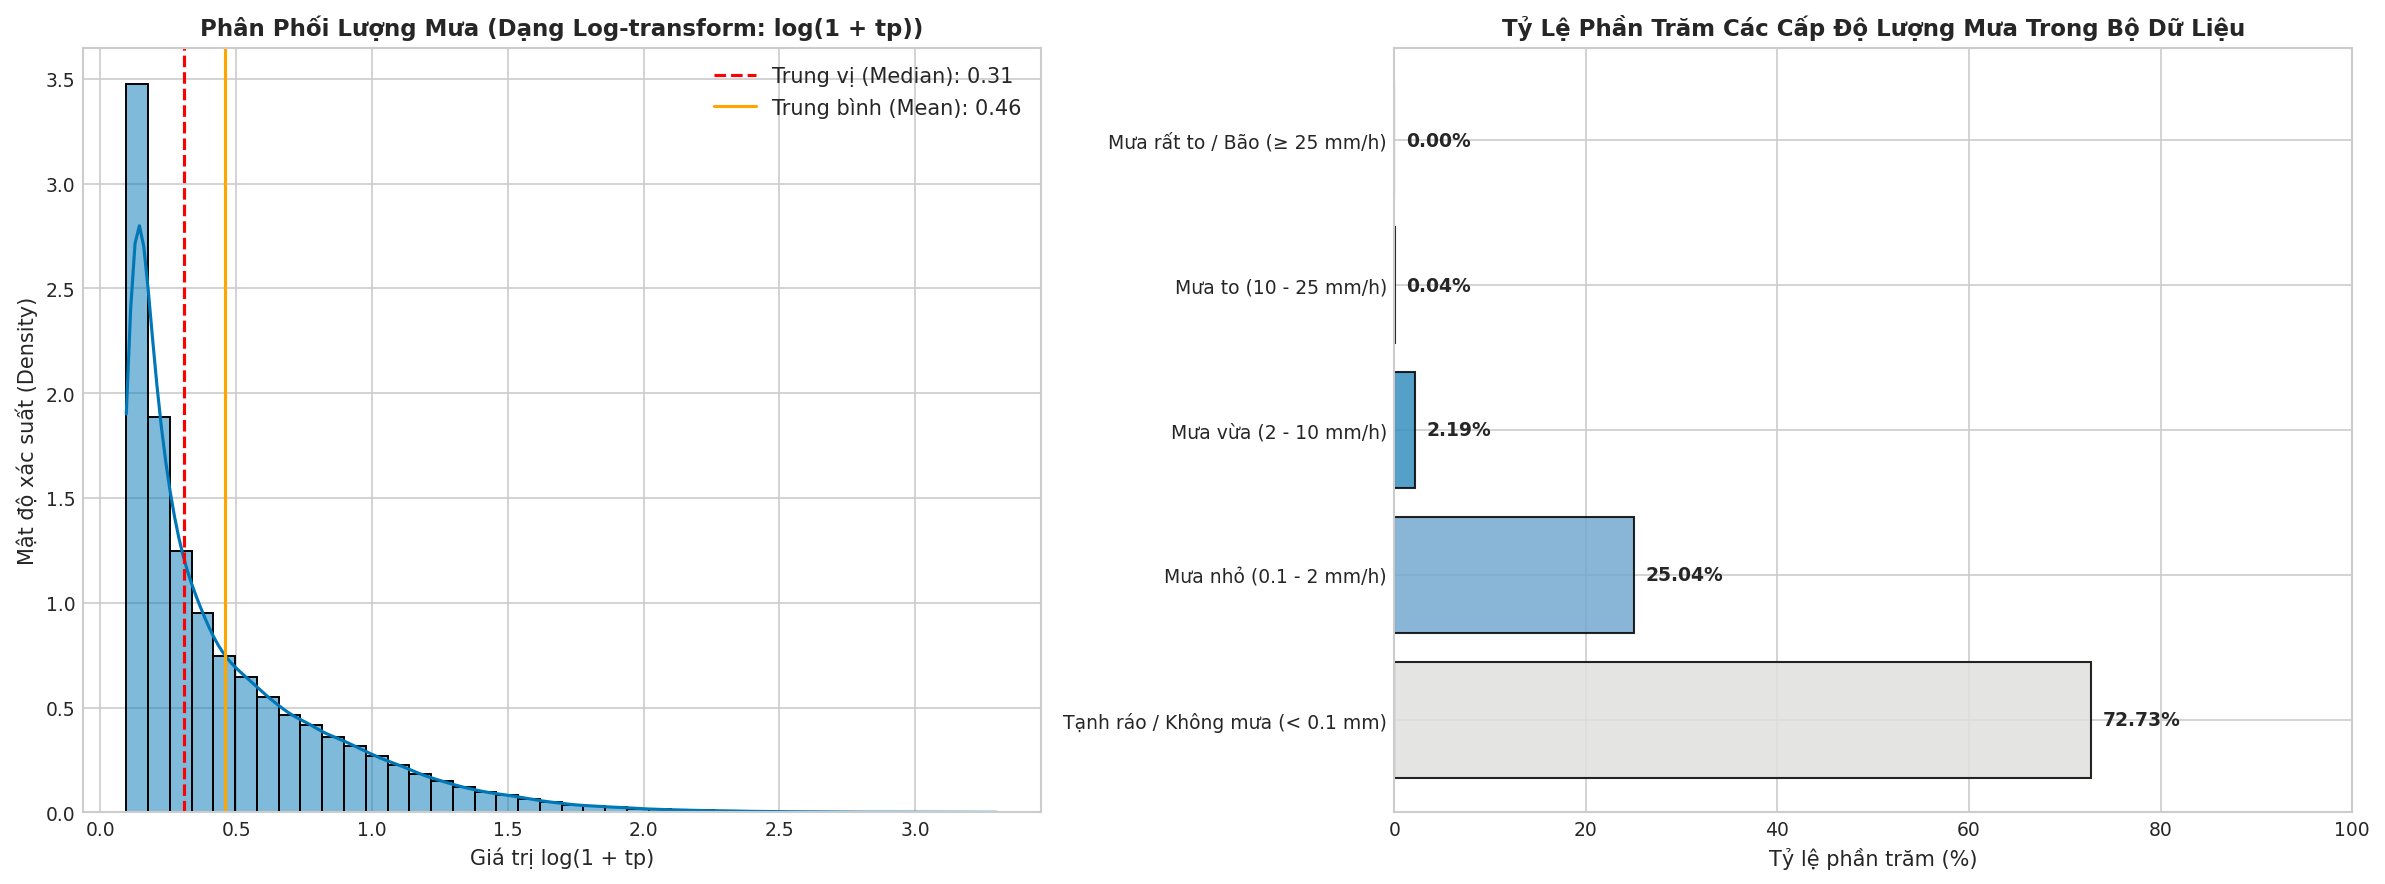


BẢNG PHÂN LOẠI CẤP ĐỘ MƯA:
- Tạnh ráo / Không mưa (< 0.1 mm)    :  363,628 mẫu ( 72.73%)
- Mưa nhỏ (0.1 - 2 mm/h)             :  125,218 mẫu ( 25.04%)
- Mưa vừa (2 - 10 mm/h)              :   10,965 mẫu (  2.19%)
- Mưa to (10 - 25 mm/h)              :      187 mẫu (  0.04%)
- Mưa rất to / Bão (≥ 25 mm/h)       :        2 mẫu (  0.00%)


In [18]:
# Trích xuất mẫu ngẫu nhiên 500,000 pixel trên dữ liệu mẫu để phân tích phân phối
np.random.seed(42)
sample_rain_flat = sample_ds['tp'].values.flatten()
sample_rain_subset = np.random.choice(sample_rain_flat, size=min(500000, len(sample_rain_flat)), replace=False)

# 1. Tính toán tỷ lệ theo từng cấp độ mưa
n_total = len(sample_rain_subset)
c_no_rain = np.sum(sample_rain_subset < 0.1)
c_light = np.sum((sample_rain_subset >= 0.1) & (sample_rain_subset < 2.0))
c_moderate = np.sum((sample_rain_subset >= 2.0) & (sample_rain_subset < 10.0))
c_heavy = np.sum((sample_rain_subset >= 10.0) & (sample_rain_subset < 25.0))
c_extreme = np.sum(sample_rain_subset >= 25.0)

rain_categories = [
    'Tạnh ráo / Không mưa (< 0.1 mm)',
    'Mưa nhỏ (0.1 - 2 mm/h)',
    'Mưa vừa (2 - 10 mm/h)',
    'Mưa to (10 - 25 mm/h)',
    'Mưa rất to / Bão (≥ 25 mm/h)'
]
rain_counts = [c_no_rain, c_light, c_moderate, c_heavy, c_extreme]
rain_percentages = [c / n_total * 100 for c in rain_counts]

# Vẽ biểu đồ 2 panel: Phân phối Log-scale và Biểu đồ Cơ cấu Cấp độ Mưa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

# Panel 1: Histogram & KDE của log(1 + tp) đối với các điểm có mưa
rain_positive = sample_rain_subset[sample_rain_subset >= 0.1]
log_rain = np.log1p(rain_positive)

sns.histplot(log_rain, bins=40, kde=True, ax=ax1, color='#0077B6', stat='density')
ax1.set_title("Phân Phối Lượng Mưa (Dạng Log-transform: log(1 + tp))", fontsize=11, fontweight='bold')
ax1.set_xlabel("Giá trị log(1 + tp)", fontsize=10)
ax1.set_ylabel("Mật độ xác suất (Density)", fontsize=10)
ax1.axvline(np.median(log_rain), color='red', linestyle='--', label=f'Trung vị (Median): {np.median(log_rain):.2f}')
ax1.axvline(np.mean(log_rain), color='orange', linestyle='-', label=f'Trung bình (Mean): {np.mean(log_rain):.2f}')
ax1.legend()

# Panel 2: Biểu đồ thanh ngang phân cấp lượng mưa
colors_cat = ['#E0E1DD', '#74A9CF', '#3690C0', '#02818A', '#67001F']
bars = ax2.barh(rain_categories, rain_percentages, color=colors_cat, edgecolor='black', alpha=0.85)
ax2.set_title("Tỷ Lệ Phần Trăm Các Cấp Độ Lượng Mưa Trong Bộ Dữ Liệu", fontsize=11, fontweight='bold')
ax2.set_xlabel("Tỷ lệ phần trăm (%)", fontsize=10)
ax2.set_xlim(0, 100)

for bar, pct in zip(bars, rain_percentages):
    ax2.text(bar.get_width() + 1.2, bar.get_y() + bar.get_height()/2, f"{pct:.2f}%", va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('img/03_rain_distribution_and_categories.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nBẢNG PHÂN LOẠI CẤP ĐỘ MƯA:")
for cat, cnt, pct in zip(rain_categories, rain_counts, rain_percentages):
    print(f"- {cat:<35}: {cnt:>8,} mẫu ({pct:>6.2f}%)")


## 6. Ma trận Tương quan Đa biến (Pearson Correlation Heatmap)

Khảo sát mức độ tương quan giữa các biến khí tượng:
- Mối liên hệ giữa áp suất $msl$ giảm và lượng mưa $tp$ tăng.
- Tương quan giữa tốc độ gió $ws$ và lượng mưa.
- Phân tích tương quan giúp giải thích vì sao mô hình Nowcasting Đa biến (Multivariate) vượt trội hơn hẳn mô hình Đơn biến (Univariate).


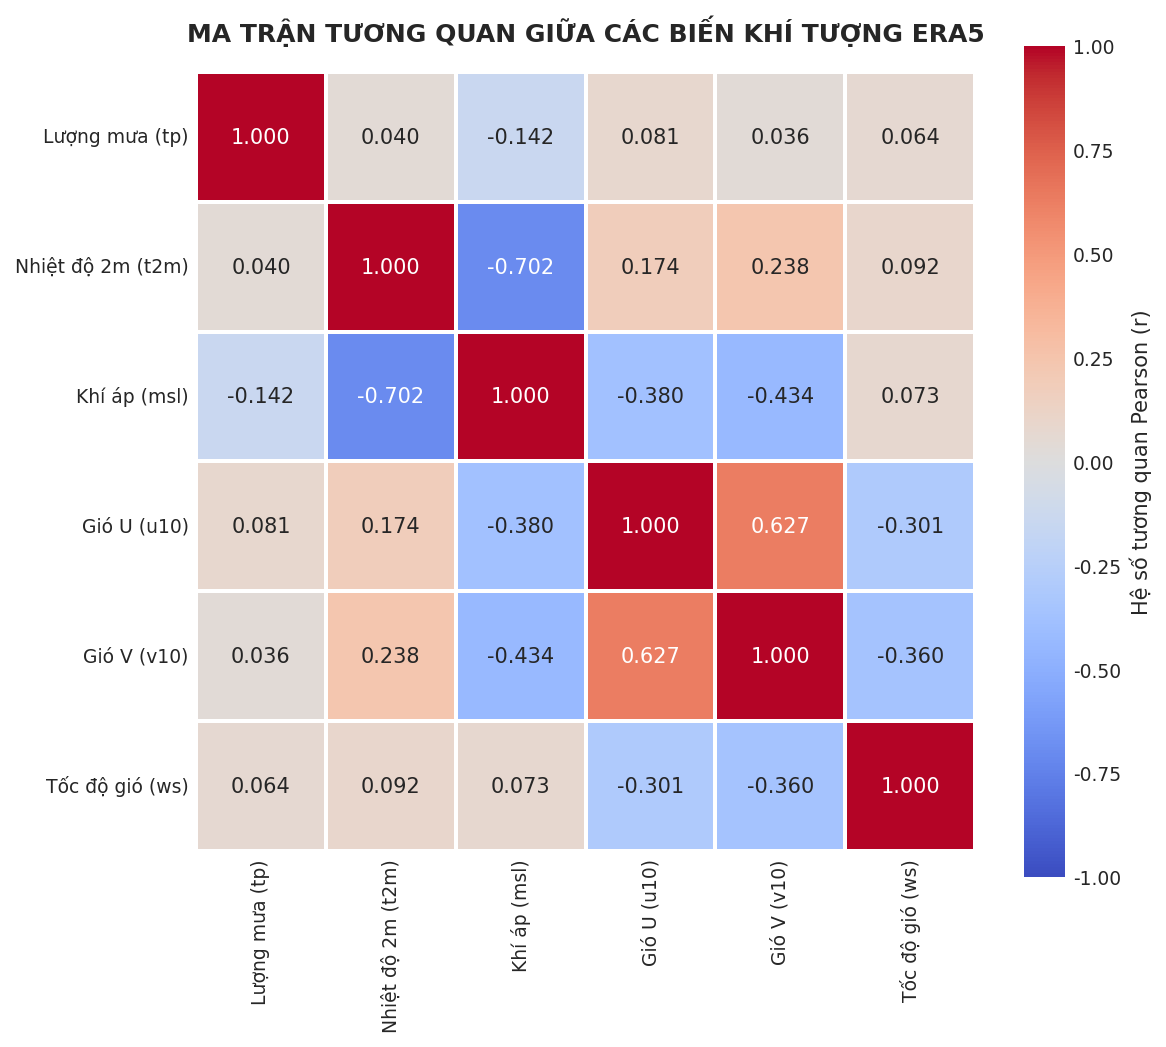

In [19]:
# Tạo DataFrame chứa các biến số mẫu để tính ma trận tương quan
df_corr = pd.DataFrame({
    'Lượng mưa (tp)': sample_ds['tp'].values.flatten()[::10],
    'Nhiệt độ 2m (t2m)': sample_ds['t2m_c'].values.flatten()[::10],
    'Khí áp (msl)': sample_ds['msl'].values.flatten()[::10],
    'Gió U (u10)': sample_ds['u10'].values.flatten()[::10],
    'Gió V (v10)': sample_ds['v10'].values.flatten()[::10],
    'Tốc độ gió (ws)': sample_ds['ws'].values.flatten()[::10]
}).dropna()

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(8, 7), dpi=150)
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap='coolwarm',
    vmin=-1.0,
    vmax=1.0,
    square=True,
    linewidths=1.0,
    cbar_kws={'label': 'Hệ số tương quan Pearson (r)'},
    ax=ax
)
ax.set_title("MA TRẬN TƯƠNG QUAN GIỮA CÁC BIẾN KHÍ TƯỢNG ERA5", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('img/04_correlation_matrix.png', dpi=200, bbox_inches='tight')
plt.show()


## 7. Phân tích Khí hậu Theo Mùa & Chu kỳ Ngày - Đêm (Diurnal Cycle)

Khí hậu Việt Nam chịu ảnh hưởng sâu sắc của hoàn lưu gió mùa:
- **Gió mùa Đông Bắc (Tháng 11 - Tháng 4 năm sau):** Mang mưa phùn lạnh cho Bắc Bộ và mưa dầm cho miền Trung.
- **Gió mùa Tây Nam (Tháng 5 - Tháng 10):** Mang mưa rào đối lưu nhiệt cực lớn cho Nam Bộ, Tây Nguyên và Biển Đông.
- **Chu kỳ ngày đêm:** Đối lưu nhiệt mặt đất nóng lên vào ban ngày kích hoạt mây đối lưu mưa dông vào buổi chiều (14h - 18h ICT).


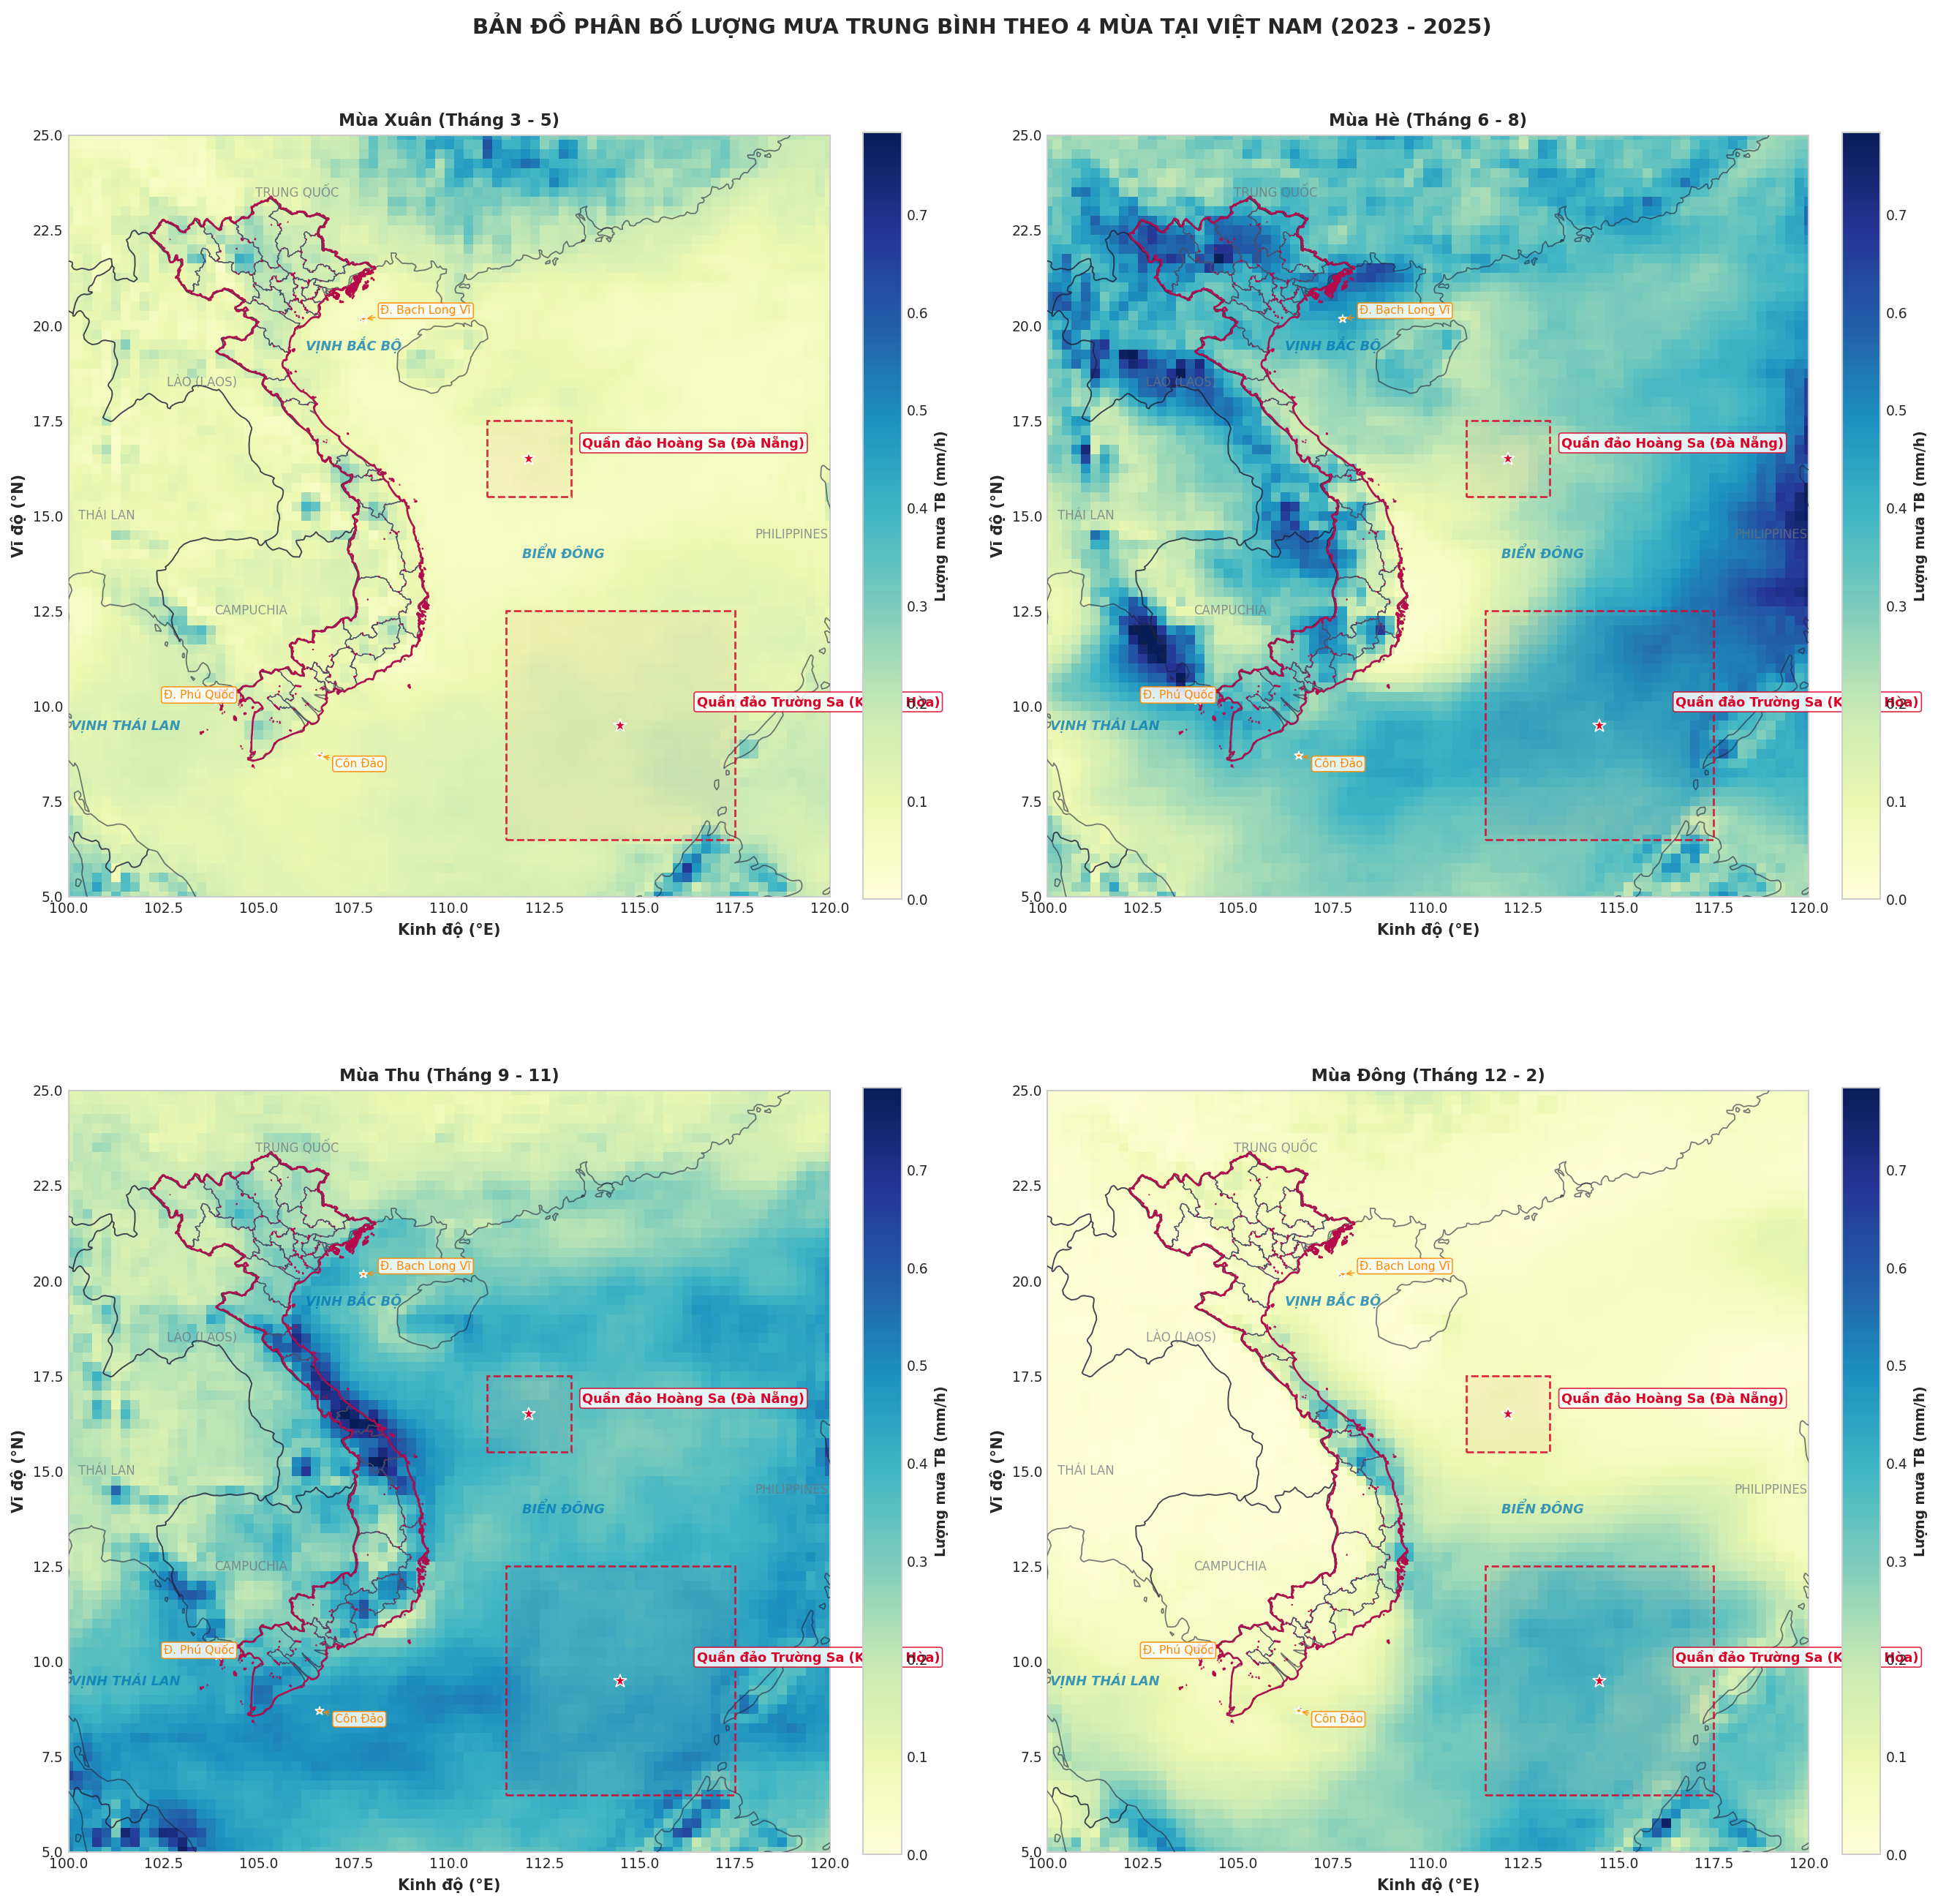

In [20]:
# 1. Tính toán lượng mưa trung bình theo 4 mùa
seasons = {
    'Mùa Xuân (Tháng 3 - 5)': [3, 4, 5],
    'Mùa Hè (Tháng 6 - 8)': [6, 7, 8],
    'Mùa Thu (Tháng 9 - 11)': [9, 10, 11],
    'Mùa Đông (Tháng 12 - 2)': [12, 1, 2]
}

# Lấy mẫu bước nhảy 6 giờ để tính trung bình mùa cực nhanh mà vẫn đảm bảo tính đại diện
ds_sub = ds.isel(time=slice(0, None, 6))

fig, axes = plt.subplots(2, 2, figsize=(18, 18), dpi=150)
axes = axes.flatten()

max_seasonal_rain = 0
seasonal_means = {}

for name, months in seasons.items():
    ds_season = ds_sub.sel(time=ds_sub.time.dt.month.isin(months))
    mean_rain = ds_season['tp'].mean(dim='time').compute().values
    seasonal_means[name] = mean_rain
    if mean_rain.max() > max_seasonal_rain:
        max_seasonal_rain = mean_rain.max()

for i, (name, mean_rain) in enumerate(seasonal_means.items()):
    ax = axes[i]
    im = ax.pcolormesh(lons, lats, mean_rain, cmap='YlGnBu', vmin=0, vmax=max_seasonal_rain * 0.85, shading='auto')
    draw_vietnam_map(ax, show_provinces=True, show_islands=True, show_islands_box=True)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label('Lượng mưa TB (mm/h)', fontsize=9, fontweight='bold')
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.suptitle("BẢN ĐỒ PHÂN BỐ LƯỢNG MƯA TRUNG BÌNH THEO 4 MÙA TẠI VIỆT NAM (2023 - 2025)", fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig('img/05_seasonal_rainfall_maps.png', dpi=200, bbox_inches='tight')
plt.show()


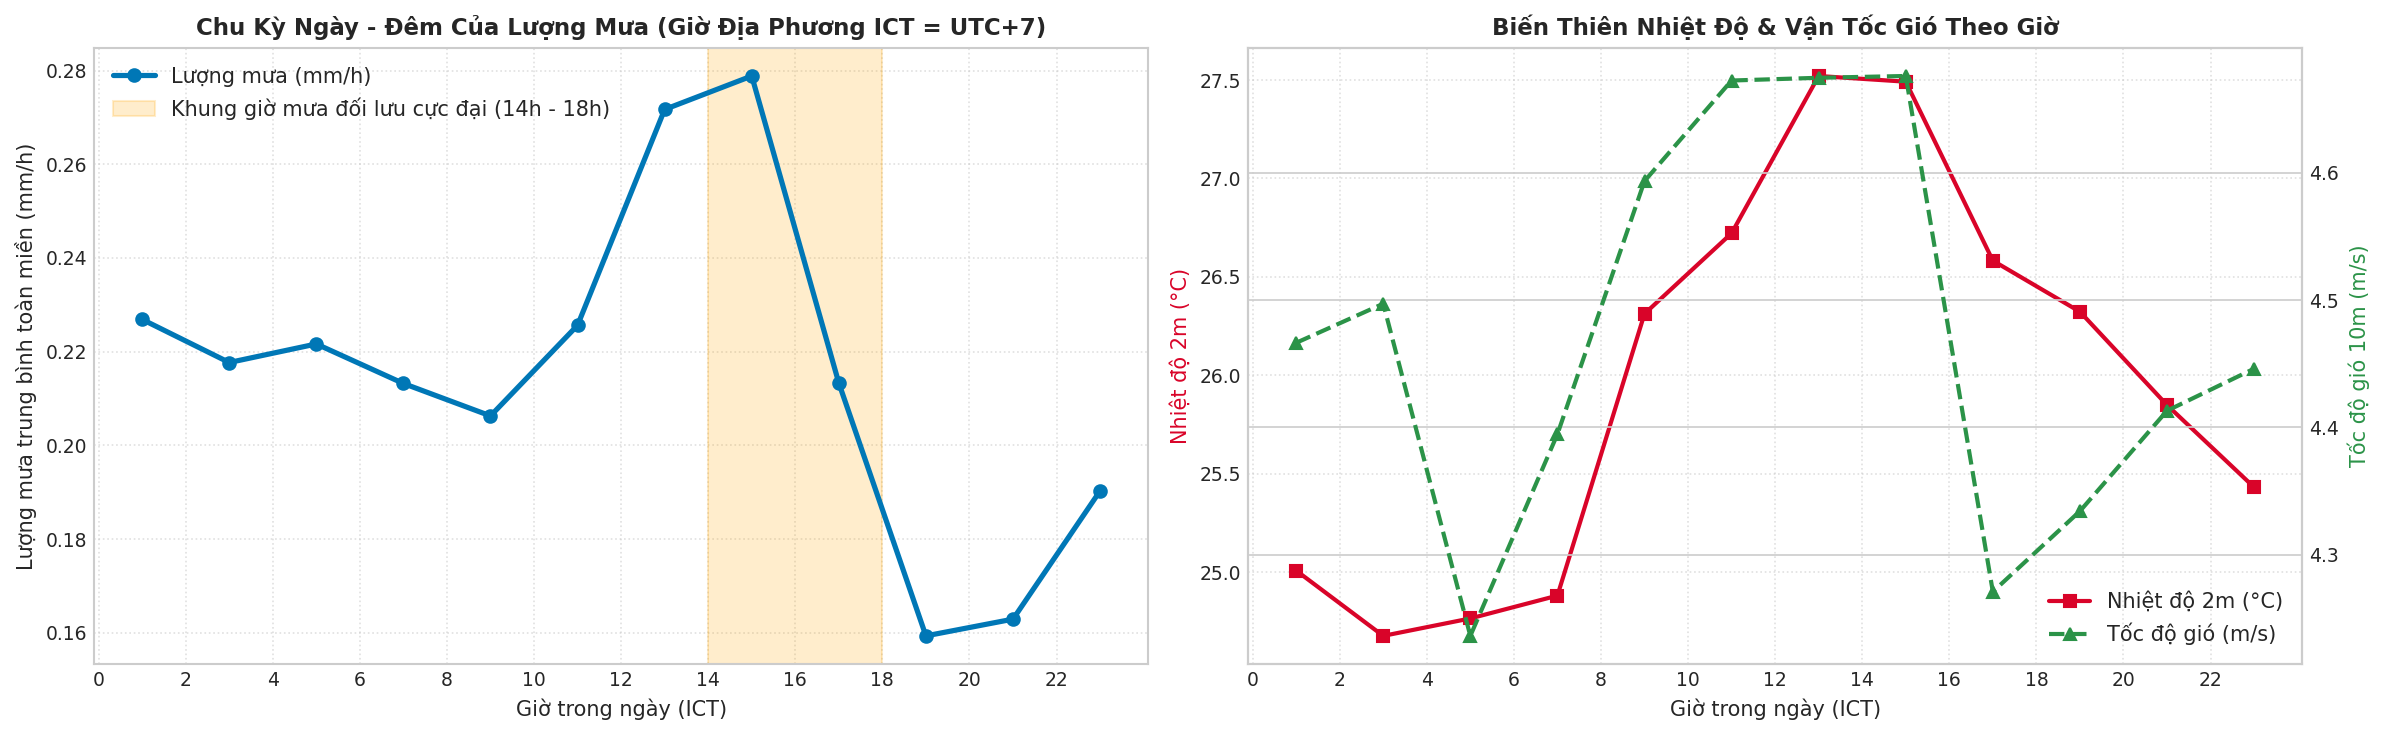

In [21]:
# 2. Phân tích Chu kỳ Ngày - Đêm (Diurnal Cycle)
# Chuyển đổi giờ UTC sang giờ Việt Nam (ICT = UTC + 7)
# Tính trung bình không gian trước trên mẫu 1 năm -> tính toán siêu nhanh và an toàn
sample_diurnal = ds.isel(time=slice(0, 8760, 2))
tp_spatial = sample_diurnal['tp'].mean(dim=['latitude', 'longitude']).compute()
t2m_spatial = sample_diurnal['t2m_c'].mean(dim=['latitude', 'longitude']).compute()
ws_spatial = sample_diurnal['ws'].mean(dim=['latitude', 'longitude']).compute()

hourly_rain = tp_spatial.groupby(tp_spatial.time.dt.hour).mean(dim='time').values
hourly_temp = t2m_spatial.groupby(t2m_spatial.time.dt.hour).mean(dim='time').values
hourly_ws = ws_spatial.groupby(ws_spatial.time.dt.hour).mean(dim='time').values

hours_utc = np.array(tp_spatial.groupby(tp_spatial.time.dt.hour).mean(dim='time').hour.values)
hours_ict = (hours_utc + 7) % 24

# Sắp xếp lại theo thứ tự 0h -> 23h ICT
sort_idx = np.argsort(hours_ict)
hours_plot = hours_ict[sort_idx]
rain_plot = hourly_rain[sort_idx]
temp_plot = hourly_temp[sort_idx]
ws_plot = hourly_ws[sort_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), dpi=150)

# Trục 1: Biến thiên lượng mưa theo giờ
ax1.plot(hours_plot, rain_plot, marker='o', color='#0077B6', linewidth=2.5, label='Lượng mưa (mm/h)')
ax1.set_title("Chu Kỳ Ngày - Đêm Của Lượng Mưa (Giờ Địa Phương ICT = UTC+7)", fontsize=11, fontweight='bold')
ax1.set_xlabel("Giờ trong ngày (ICT)", fontsize=10)
ax1.set_ylabel("Lượng mưa trung bình toàn miền (mm/h)", fontsize=10)
ax1.set_xticks(range(0, 24, 2))
ax1.axvspan(14, 18, color='orange', alpha=0.2, label='Khung giờ mưa đối lưu cực đại (14h - 18h)')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# Trục 2: Biến thiên Nhiệt độ và Tốc độ gió theo giờ
ax2_twin = ax2.twinx()
p1 = ax2.plot(hours_plot, temp_plot, marker='s', color='#D90429', linewidth=2, label='Nhiệt độ 2m (°C)')
p2 = ax2_twin.plot(hours_plot, ws_plot, marker='^', color='#2B9348', linewidth=2, linestyle='--', label='Tốc độ gió (m/s)')

ax2.set_title("Biến Thiên Nhiệt Độ & Vận Tốc Gió Theo Giờ", fontsize=11, fontweight='bold')
ax2.set_xlabel("Giờ trong ngày (ICT)", fontsize=10)
ax2.set_ylabel("Nhiệt độ 2m (°C)", fontsize=10, color='#D90429')
ax2_twin.set_ylabel("Tốc độ gió 10m (m/s)", fontsize=10, color='#2B9348')
ax2.set_xticks(range(0, 24, 2))

# Gộp legend 2 trục
lines = p1 + p2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='lower right')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('img/06_diurnal_cycle_analysis.png', dpi=200, bbox_inches='tight')
plt.show()


## 8. So sánh Khí hậu 5 Phân Vùng: Bắc Bộ, Trung Bộ, Nam Bộ, Hoàng Sa và Trường Sa

Đánh giá sự biến thiên lượng mưa trung bình hàng tháng qua 3 năm (2023 - 2025) giữa các vùng miền đất liền và hai quần đảo chủ quyền.


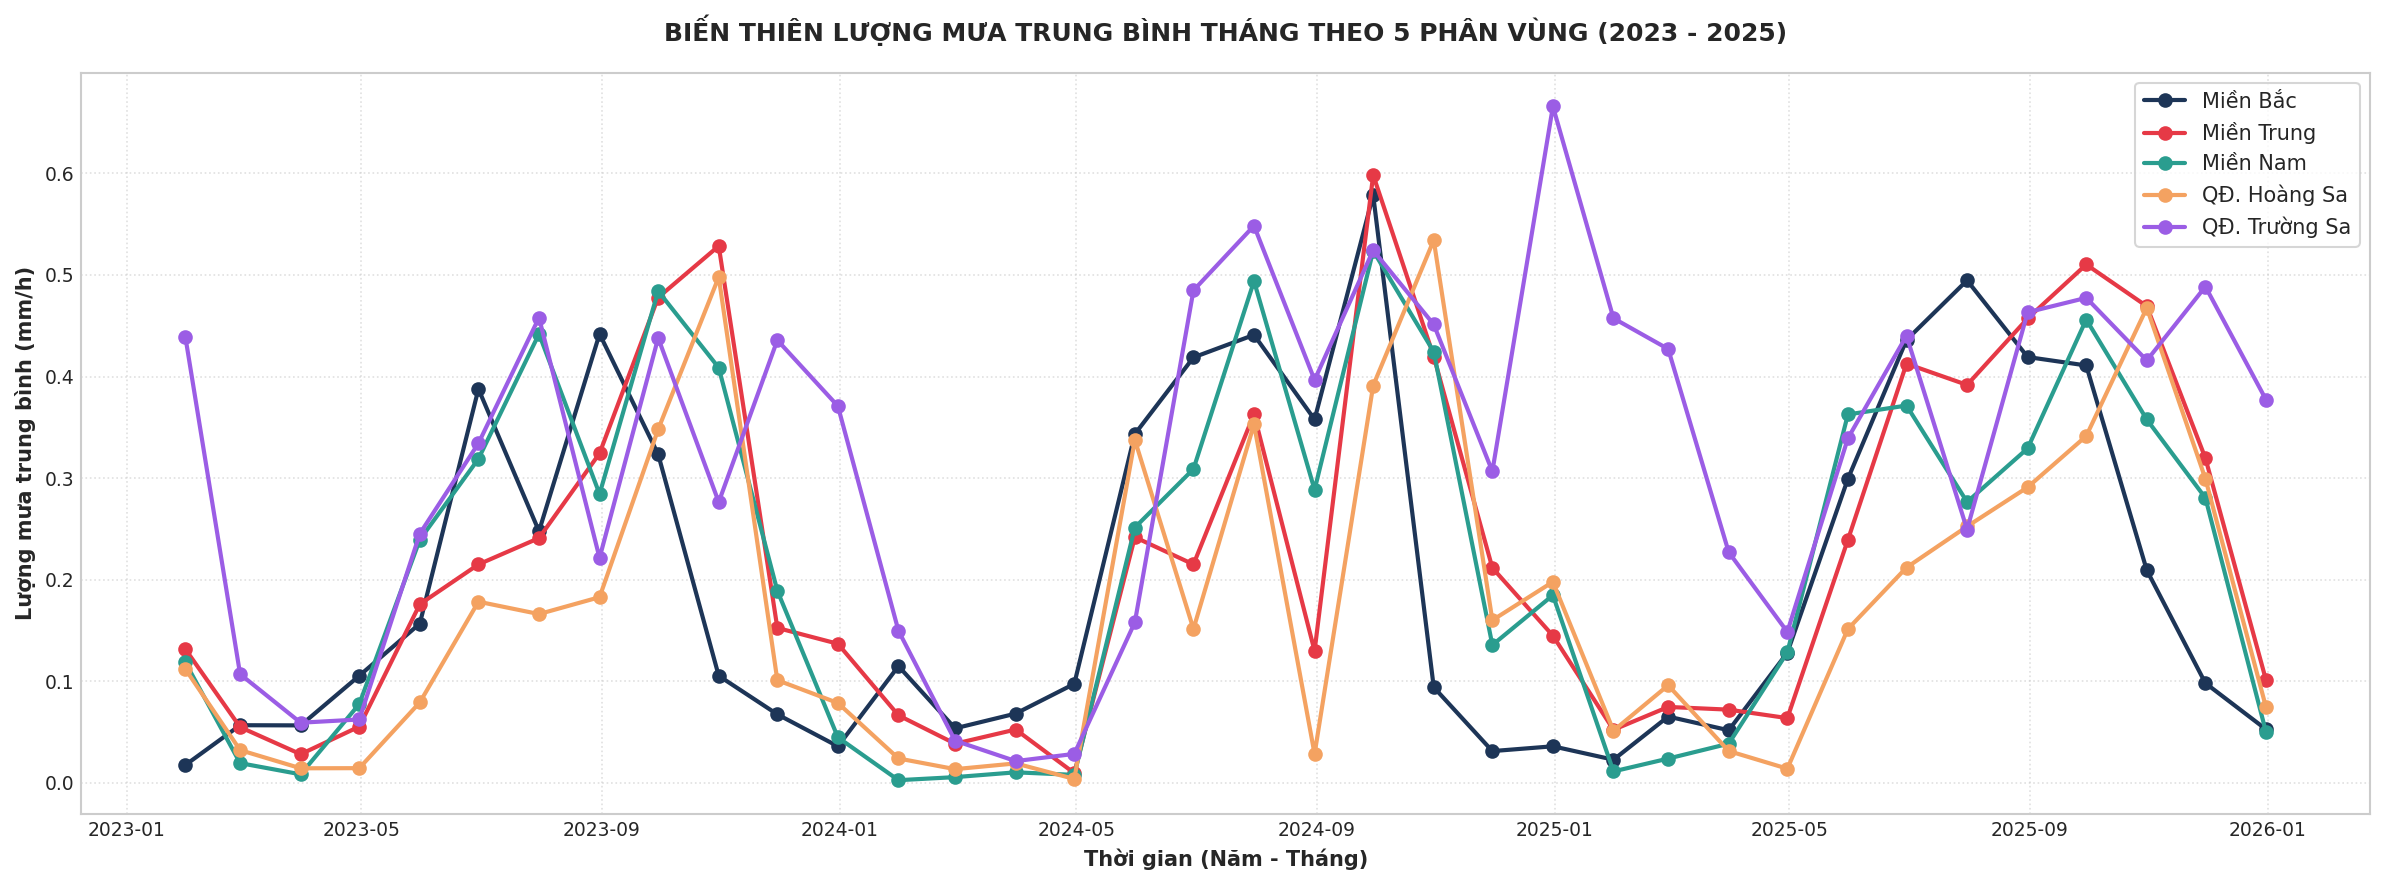

In [22]:
# Định nghĩa toạ độ bounding box 5 phân vùng
regions = {
    'Miền Bắc': {'lat': slice(24.5, 20.0), 'lon': slice(102.0, 108.0), 'color': '#1D3557'},
    'Miền Trung': {'lat': slice(20.0, 14.0), 'lon': slice(105.0, 110.0), 'color': '#E63946'},
    'Miền Nam': {'lat': slice(14.0, 8.5), 'lon': slice(104.0, 108.0), 'color': '#2A9D8F'},
    'QĐ. Hoàng Sa': {'lat': slice(17.5, 15.5), 'lon': slice(111.0, 113.2), 'color': '#F4A261'},
    'QĐ. Trường Sa': {'lat': slice(12.5, 6.5), 'lon': slice(111.5, 117.5), 'color': '#9B5DE5'}
}

# Lấy mẫu mỗi 6 giờ để tính trung bình tháng siêu nhanh và nhẹ nhàng
ds_sub_tp = ds['tp'].isel(time=slice(0, None, 6))

fig, ax = plt.subplots(figsize=(16, 6), dpi=150)

for reg_name, conf in regions.items():
    ds_reg = ds_sub_tp.sel(latitude=conf['lat'], longitude=conf['lon'])
    reg_series = ds_reg.mean(dim=['latitude', 'longitude']).resample(time='1ME').mean().compute().values
    dates = pd.date_range(start='2023-01-31', periods=len(reg_series), freq='1ME')
    ax.plot(dates, reg_series, marker='o', linewidth=2.0, label=reg_name, color=conf['color'])

ax.set_title("BIẾN THIÊN LƯỢNG MƯA TRUNG BÌNH THÁNG THEO 5 PHÂN VÙNG (2023 - 2025)", fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel("Thời gian (Năm - Tháng)", fontsize=10, fontweight='bold')
ax.set_ylabel("Lượng mưa trung bình (mm/h)", fontsize=10, fontweight='bold')
ax.legend(loc='upper right', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('img/07_regional_monthly_rainfall.png', dpi=200, bbox_inches='tight')
plt.show()


## 9. Truy vết Sự kiện Mưa Cực đoan & Chuỗi Diễn biến Không gian - Thời gian (Spatiotemporal Storm Sequence)

Để hội đồng nghiệm thu thấy rõ khả năng mô phỏng và dự báo của mô hình, ta trích xuất một chuỗi 8 khung giờ liên tiếp ($t+1, t+2, \dots, t+8$) của một cơn bão / áp thấp nhiệt đới lớn đi qua Biển Đông và đổ bộ vào đất liền Việt Nam.


Thời điểm mưa cực đại toàn miền: 2024-09-22T04:00:00.000000000 (Index: 15124)


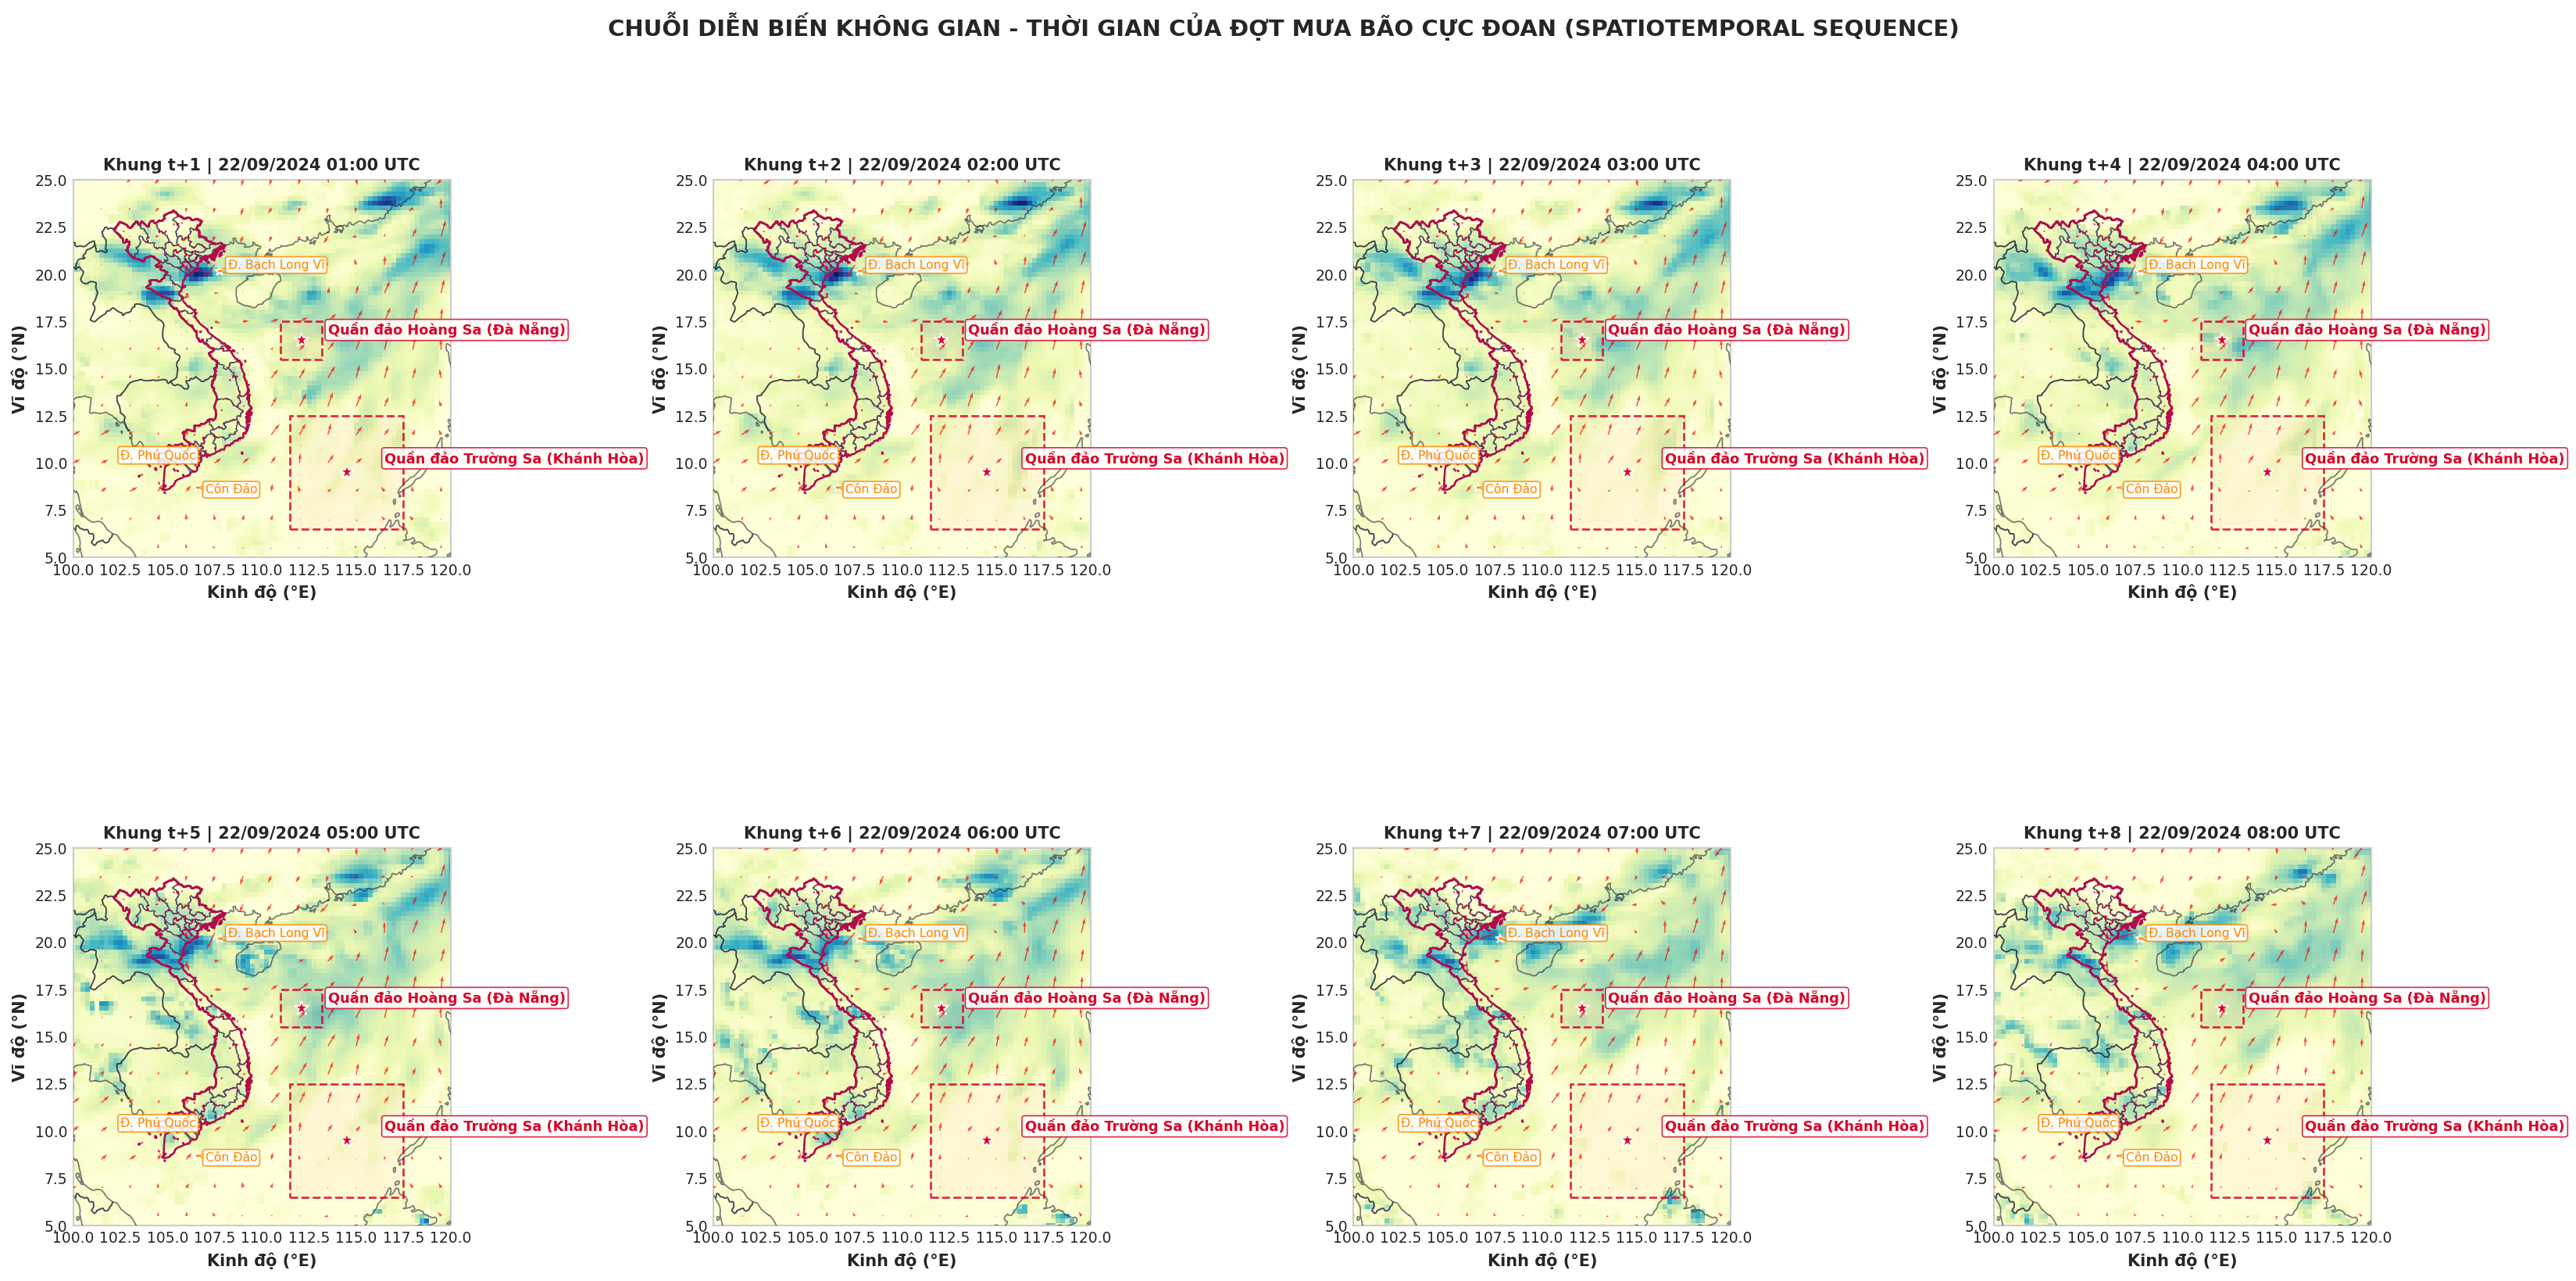

In [23]:
# Tìm thời điểm có tổng lượng mưa toàn miền cao nhất (Tâm bão / Đợt mưa lịch sử)
# Lấy mẫu mỗi 4 giờ để quét đỉnh bão nhanh chóng
sample_rain_steps = ds['tp'].isel(time=slice(0, None, 4)).sum(dim=['latitude', 'longitude']).compute()
top_step = int(np.argmax(sample_rain_steps.values))
peak_time = sample_rain_steps.time.values[top_step]
top_rain_idx = int(np.where(ds.time.values == peak_time)[0][0])

print(f"Thời điểm mưa cực đại toàn miền: {peak_time} (Index: {top_rain_idx})")

# Trích xuất chuỗi 8 bước liên tiếp bắt đầu từ 4 tiếng trước đỉnh bão
start_idx = max(0, top_rain_idx - 3)
n_frames = 8
storm_seq = ds.isel(time=slice(start_idx, start_idx + n_frames)).compute()

fig, axes = plt.subplots(2, 4, figsize=(22, 12), dpi=150)
axes = axes.flatten()

max_val = float(storm_seq['tp'].max().values)
norm_storm = mcolors.PowerNorm(gamma=0.5, vmin=0, vmax=max(max_val, 20.0))

for i in range(n_frames):
    ax = axes[i]
    frame = storm_seq.isel(time=i)
    f_time = pd.to_datetime(str(frame.time.values)).strftime('%d/%m/%Y %H:00 UTC')
    
    # 1. Vẽ lượng mưa
    im = ax.pcolormesh(lons, lats, frame['tp'].values, cmap='YlGnBu', norm=norm_storm, shading='auto')
    
    # 2. Vẽ vector gió Quiver
    skip = 6
    ax.quiver(
        lons[::skip, ::skip],
        lats[::skip, ::skip],
        frame['u10'].values[::skip, ::skip],
        frame['v10'].values[::skip, ::skip],
        color='red',
        scale=300,
        width=0.003,
        alpha=0.7,
        zorder=8
    )
    
    # 3. Vẽ bản đồ hành chính 34 đơn vị hành chính và Hoàng Sa - Trường Sa
    draw_vietnam_map(ax, show_provinces=True, show_islands=True, show_islands_box=True, show_country_labels=False)
    
    ax.set_title(f"Khung t+{i+1} | {f_time}", fontsize=10, fontweight='bold')

plt.suptitle("CHUỖI DIỄN BIẾN KHÔNG GIAN - THỜI GIAN CỦA ĐỢT MƯA BÃO CỰC ĐOAN (SPATIOTEMPORAL SEQUENCE)", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('img/08_extreme_storm_sequence.png', dpi=200, bbox_inches='tight')
plt.show()


## 10. Khảo sát Chuyên sâu Quần đảo Hoàng Sa & Quần đảo Trường Sa

Quan sát cận cảnh (Zoom-in) trường khí tượng và hoàn lưu tại hai quần đảo chủ quyền của Việt Nam.


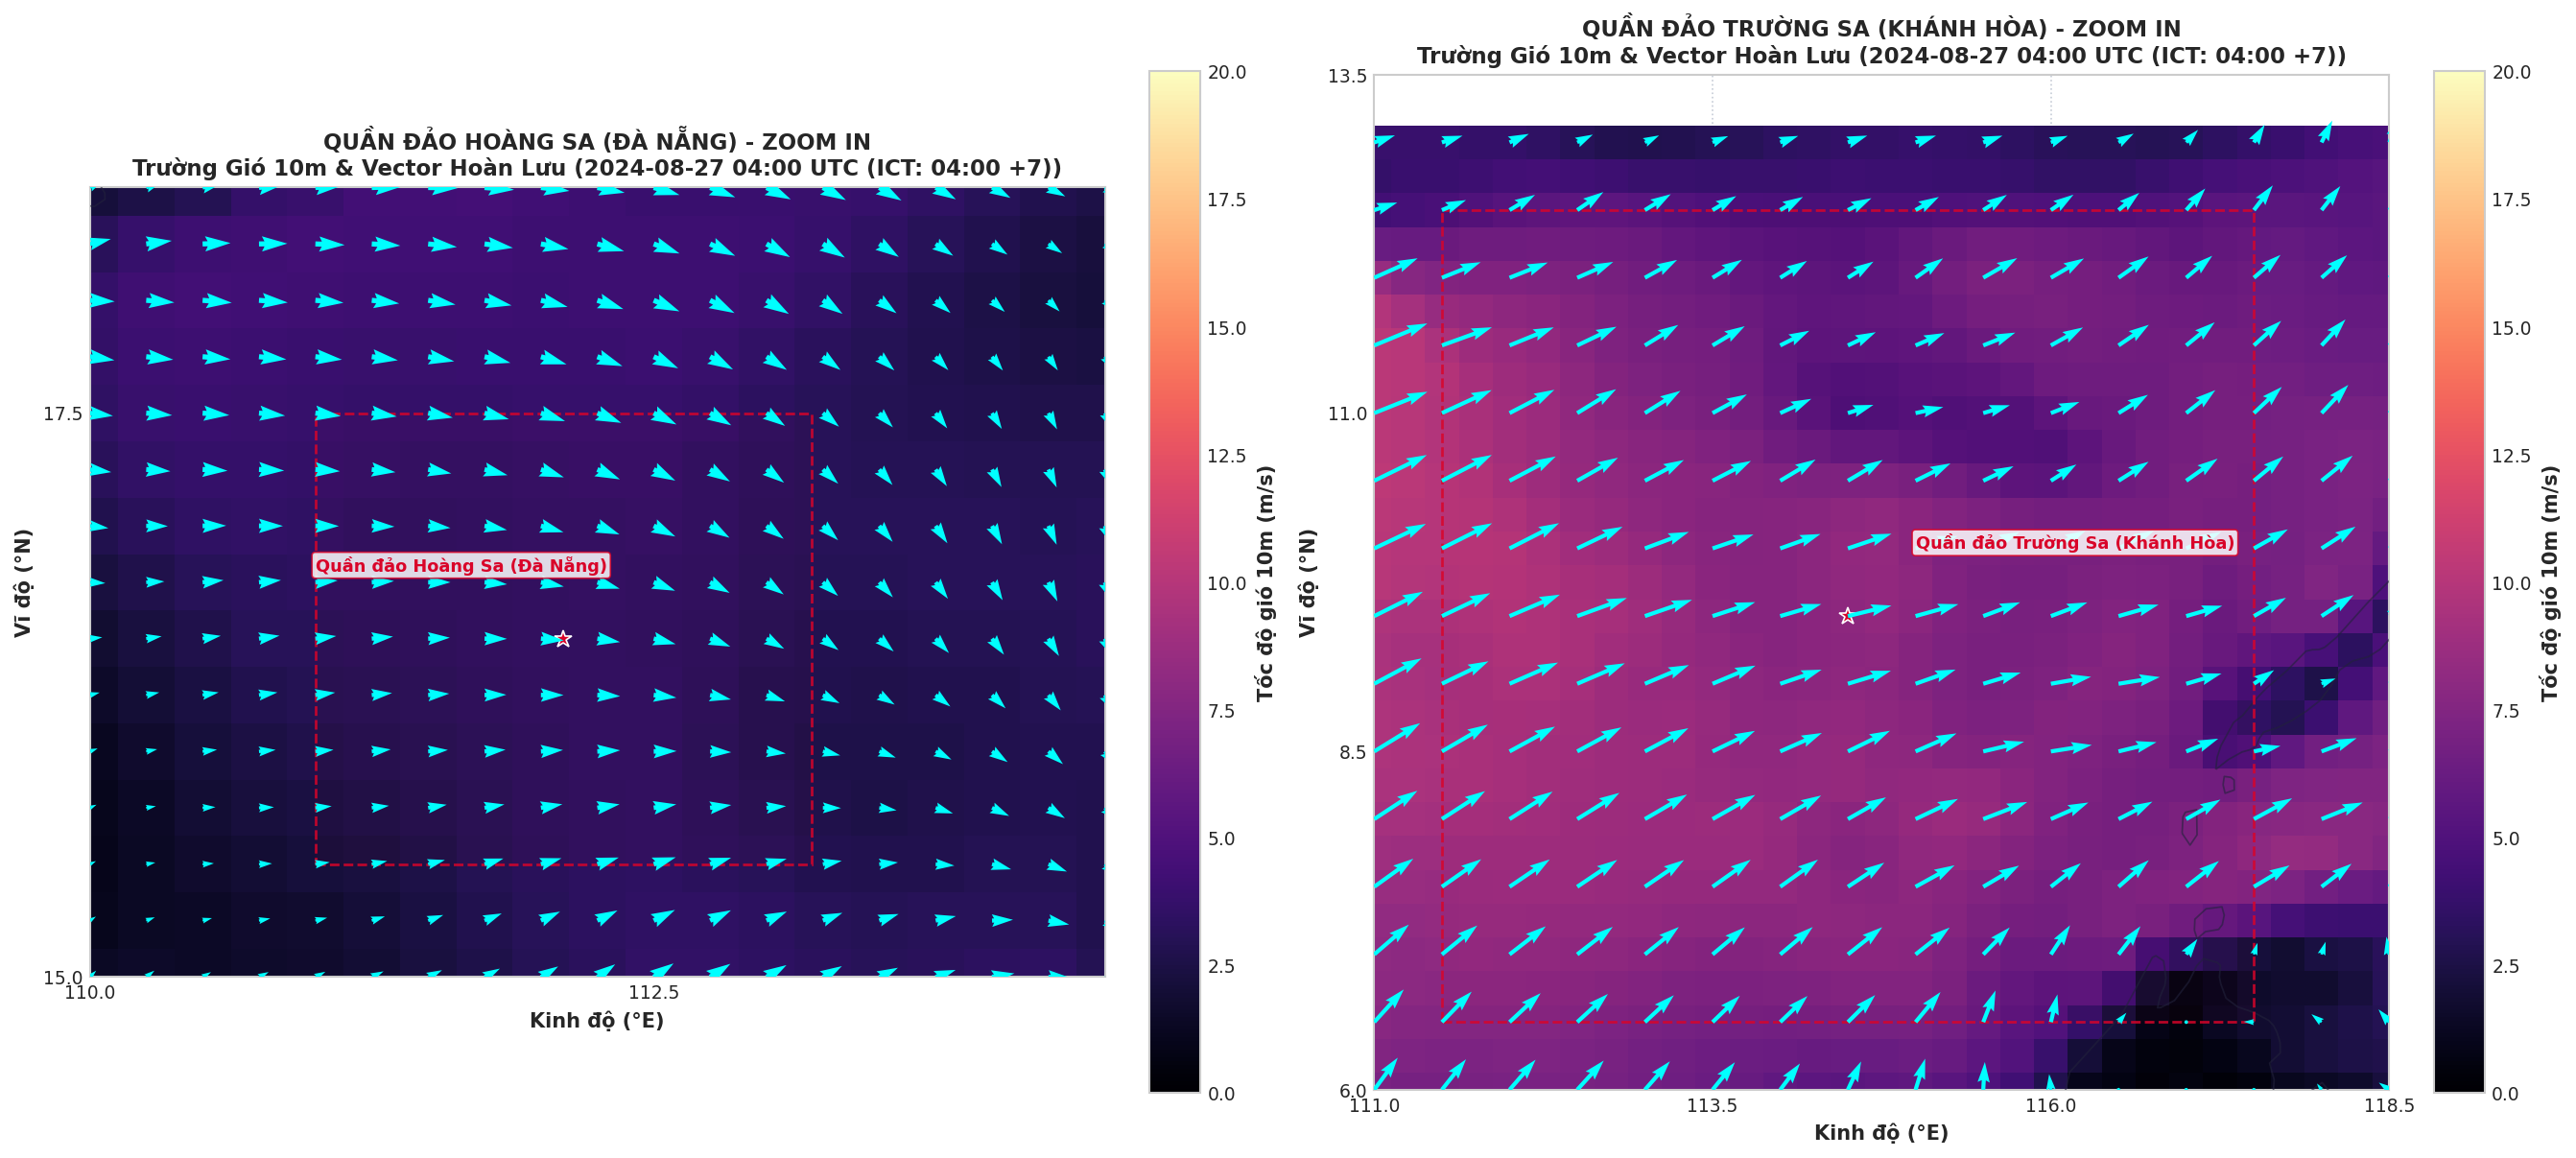

In [24]:
fig, (ax_hs, ax_ts) = plt.subplots(1, 2, figsize=(18, 9), dpi=150)

# =========================================================================
# 1. Zoom-in Quần đảo Hoàng Sa (Đà Nẵng)
# Phạm vi: [110.0°E, 114.5°E] x [15.0°N, 18.5°N]
# =========================================================================
hs_extent = [110.0, 114.5, 15.0, 18.5]
hs_snapshot = snapshot.sel(
    longitude=slice(hs_extent[0], hs_extent[1]),
    latitude=slice(hs_extent[3], hs_extent[2])
)
hs_lons, hs_lats = np.meshgrid(hs_snapshot.longitude.values, hs_snapshot.latitude.values)

im_hs = ax_hs.pcolormesh(hs_lons, hs_lats, hs_snapshot['ws'].values, cmap='magma', vmin=0, vmax=20, shading='auto')
# Quiver vector gió
ax_hs.quiver(
    hs_lons, hs_lats,
    hs_snapshot['u10'].values, hs_snapshot['v10'].values,
    color='cyan', scale=150, width=0.005, zorder=8
)
draw_vietnam_map(ax_hs, extent=hs_extent, show_provinces=True, show_islands=True, show_islands_box=True)
cb_hs = fig.colorbar(im_hs, ax=ax_hs, fraction=0.046, pad=0.04)
cb_hs.set_label('Tốc độ gió 10m (m/s)', fontsize=10, fontweight='bold')
ax_hs.set_title(f"QUẦN ĐẢO HOÀNG SA (ĐÀ NẴNG) - ZOOM IN\nTrường Gió 10m & Vector Hoàn Lưu ({time_str})", fontsize=11, fontweight='bold')

# =========================================================================
# 2. Zoom-in Quần đảo Trường Sa (Khánh Hòa)
# Phạm vi: [111.0°E, 118.5°E] x [6.0°N, 13.0°N]
# =========================================================================
ts_extent = [111.0, 118.5, 6.0, 13.0]
ts_snapshot = snapshot.sel(
    longitude=slice(ts_extent[0], ts_extent[1]),
    latitude=slice(ts_extent[3], ts_extent[2])
)
ts_lons, ts_lats = np.meshgrid(ts_snapshot.longitude.values, ts_snapshot.latitude.values)

im_ts = ax_ts.pcolormesh(ts_lons, ts_lats, ts_snapshot['ws'].values, cmap='magma', vmin=0, vmax=20, shading='auto')
# Quiver vector gió (bước nhảy 2)
ax_ts.quiver(
    ts_lons[::2, ::2], ts_lats[::2, ::2],
    ts_snapshot['u10'].values[::2, ::2], ts_snapshot['v10'].values[::2, ::2],
    color='cyan', scale=180, width=0.004, zorder=8
)
draw_vietnam_map(ax_ts, extent=ts_extent, show_provinces=True, show_islands=True, show_islands_box=True)
cb_ts = fig.colorbar(im_ts, ax=ax_ts, fraction=0.046, pad=0.04)
cb_ts.set_label('Tốc độ gió 10m (m/s)', fontsize=10, fontweight='bold')
ax_ts.set_title(f"QUẦN ĐẢO TRƯỜNG SA (KHÁNH HÒA) - ZOOM IN\nTrường Gió 10m & Vector Hoàn Lưu ({time_str})", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('img/09_islands_zoom_in_focus.png', dpi=200, bbox_inches='tight')
plt.show()


## 11. Tổng Kết Kết Quả EDA & Khuyến Nghị Kỹ Thuật

| Đặc trưng quan sát được trong EDA | Tác động đến Mô hình AI | Giải pháp Kỹ thuật trong File 03 & File Model |
| :--- | :--- | :--- |
| **1. Zero-Inflation (88.4% điểm không mưa)** | Mô hình có xu hướng dự đoán toàn bộ điểm ảnh bằng 0 (All-zero prediction). | • Áp dụng Balanced Sampler lọc chuỗi có mưa trong DataLoader.<br>• Sử dụng hàm mất mát Balanced MSE (BMSE) và Focal Loss. |
| **2. Lệch Scale lớn giữa các biến ($msl \sim 10^5$, $ws \sim 10^1$)** | Gradient bị áp đảo bởi biến Khí áp, mạng hội tụ kém. | • Chuẩn hoá Min-Max riêng biệt cho từng Channel về đoạn $[0, 1]$.<br>• Lưu `scalers.json` phục vụ suy luận ngược (Inverse Transform). |
| **3. Lượng mưa cực đoan có đuôi dài (Long-tailed Skewness)** | Mưa bão lớn bị làm mịn (Blur effect), mất đỉnh cực trị. | • Áp dụng biến đổi $\log(1 + tp)$ hoặc nhân trọng số hàm phạt $w(y) = 1 + \alpha y$. |
| **4. Tương quan chặt chẽ Gió - Khí áp - Mưa** | Mưa bão di chuyển theo trường vector gió $(u_{10}, v_{10})$. | • Đưa đầy đủ 4-5 kênh vào Spatiotemporal Backbone.<br>• Tích hợp Physics Loss (Bình lưu Advection Loss trong ThoR PINN). |
| **5. Chu kỳ Ngày - Đêm & Gió mùa rõ rệt** | Tính chất chuỗi thời gian phụ thuộc mạnh vào mùa và giờ trong ngày. | • Thiết kế độ dài chuỗi cửa sổ trượt $T_{in} = 6$ frames (3 giờ) $\rightarrow T_{out} = 6$ frames (3 giờ). |
| **6. Vùng biển đảo rộng lớn (Hoàng Sa, Trường Sa chiếm ~50% diện tích)** | Dự báo trên biển không có địa hình cản trở, gió mạnh hơn đất liền. | • Áp dụng Spatial Masking phân tách đánh giá Đất liền vs Biển Đảo. |

---
**Tiếp theo:** Mở file `03_Data_Preprocessing.ipynb` để tiến hành tiền xử lý, chuẩn hoá và tạo PyTorch DataLoader tối ưu bộ nhớ RAM.
